In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, ArrowStyle
from matplotlib.gridspec import GridSpecFromSubplotSpec
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib.colors import to_rgb
from matplotlib.lines import Line2D
from matplotlib.patheffects import withStroke

import networkx as nx

import os
import os.path as op

import importlib

import dgsp
import graph_examples as dgsp_graphs
import plotting as dgsp_plot

import bimod_plots as plot

import matplotlib
#matplotlib.rcParams['axes.linewidth'] = 1
#matplotlib.rcParams['xtick.major.width'] = 1
#matplotlib.rcParams['ytick.major.width'] = 1

In [2]:
# path_to_figures = "/Users/acionca/Google Drive/My Drive/01-Work/01-EDEE/_Candidacy/Figures"
path_to_figures = "/Users/acionca/Google Drive/My Drive/01-Work/01-EDEE/papers/104-EUSIPCO_BrainBicom/Figures"

os.makedirs(path_to_figures, exist_ok=True)

inch_to_cm = 2.54
cm_to_inch = 1/inch_to_cm

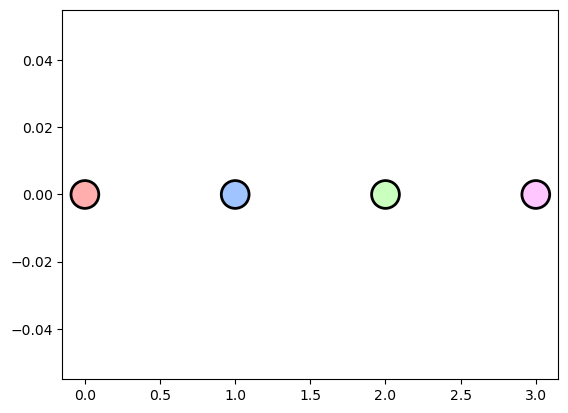

In [3]:
colorpalette = ["#FFADAD", "#A0C4FF", "#CAFFBF", "#FFC6FF"]
palette_rgb = [to_rgb(color) for color in colorpalette]

colors_edges = np.array(["tab:red", "tab:blue", "tab:green", "tab:gray"])
markers = ["s", "o", "D", "^"]

plot.plot_palette()

os.makedirs(path_to_figures, exist_ok=True)

# Graph plots constants
edge_a=.2
edge_cs="arc3,rad=0.2"

([], [])

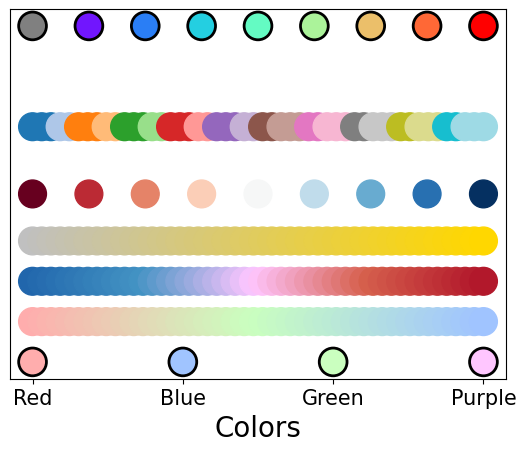

In [4]:
from matplotlib.colors import LinearSegmentedColormap
n_samples = 10
#orig_cmap = plt.get_cmap("Spectral", n_samples+1)
orig_cmap = plt.get_cmap("gist_rainbow", n_samples)
orig_cmap = plt.get_cmap("rainbow", n_samples)
#colorlist = ["gray"] + [orig_cmap(i) for i in range(n_samples//2)] + [orig_cmap(n_samples//2+i+1) for i in range(n_samples//2)]
colorlist = ["gray"] + [orig_cmap(i) for i in range(n_samples)]
custom_cmap = LinearSegmentedColormap.from_list("", colorlist)

plt.scatter([0, 1, 2, 3], [0]*4, c=palette_rgb, s=400, edgecolors="k", lw=2)
plt.scatter(np.linspace(0, 3, 9), [0.5]*9, c=np.arange(9), cmap=custom_cmap, s=400, edgecolors="k", lw=2)

plt.scatter(np.linspace(0, 3, 9), [0.25]*9, c=np.arange(9), cmap="RdBu", s=400)

n_rdbu = 11
RdBu = plt.get_cmap("RdBu", n_rdbu)
purple_def = orig_cmap(0)
purple_def = palette_rgb[-1]
#purple_def = "tab:purple"

color_offset = 1
RedPurpleBlue_list = [RdBu(color_offset), purple_def , RdBu(n_rdbu-color_offset-1)]
RedPurpleBlue_list = [RdBu(color_offset), RdBu(2*color_offset), purple_def , RdBu(n_rdbu-2*color_offset-1), RdBu(n_rdbu-color_offset-1)]
RedPurpleBlue = LinearSegmentedColormap.from_list("", RedPurpleBlue_list)

RedPurpleBlue = RedPurpleBlue.reversed()


color_offset = 1
#Gray2Green_list = ["silver", "tab:green"]
Gray2Green_list = ["silver", "gold"]
Gray2Green = LinearSegmentedColormap.from_list("", Gray2Green_list)

Palette_cmap = LinearSegmentedColormap.from_list("", [palette_rgb[0], palette_rgb[2], palette_rgb[1]])

n_plots = 50
plt.scatter(np.linspace(0, 3, n_plots), [0.12]*n_plots, c=np.arange(n_plots), cmap=RedPurpleBlue.resampled(n_plots), s=400)
plt.scatter(np.linspace(0, 3, n_plots), [0.18]*n_plots, c=np.arange(n_plots), cmap=Gray2Green.resampled(n_plots), s=400)
plt.scatter(np.linspace(0, 3, n_plots), [0.35]*n_plots, c=np.arange(n_plots), cmap="tab20", s=400)
plt.scatter(np.linspace(0, 3, n_plots), [0.06]*n_plots, c=np.arange(n_plots), cmap=Palette_cmap.resampled(n_plots), s=400)

plt.xlabel("Colors", fontsize=20)
plt.xticks([0, 1, 2, 3], ["Red", "Blue", "Green", "Purple"], fontsize=15)

plt.yticks([])

(0.3, 0.6)

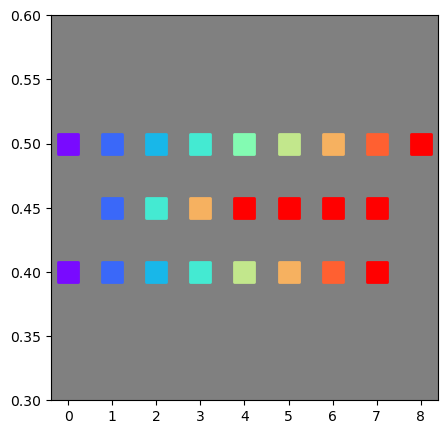

In [5]:
nclust = 9
fig, axes = plt.subplots(figsize=(5, 5))
for i in range(nclust):
    axes.scatter(i, 0.5, color=custom_cmap.resampled(nclust+1)(i+1), s=200, marker="s", lw=2)

axes.set_facecolor("gray")

orig_cmap = plt.get_cmap("rainbow", n_samples)
colorlist = ["gray"] + [orig_cmap(i) for i in range(n_samples)]
custom_cmap = LinearSegmentedColormap.from_list("", colorlist)

exclude = [3, 4]
exclude = [4, 5]
exclude = [4]
cluster_colors8 = [custom_cmap.resampled(nclust+1)(i+1) for i in range(nclust) if i not in exclude]

cmap_8clusters = LinearSegmentedColormap.from_list("", ["gray"] + cluster_colors8)

for i in range(8):
    axes.scatter(i, 0.4, color=cluster_colors8[i], s=200, marker="s", lw=2)
    
    axes.scatter(i, 0.45, color=cmap_8clusters.resampled(5)(i), s=200, marker="s", lw=2)

axes.set_ylim(0.3, 0.6)

# SVD Signs !!

In [ ]:
n_per_com = 10

base_density = 0.8

assort = False
con_densities = 0.1 + 0.8 * assort

dir_densities = 0.5

graph = dgsp_graphs.toy_n_communities(n_per_com, 4, com_density=base_density*con_densities,
                                        connect_density=[base_density*con_densities,
                                                        base_density*(1-con_densities),
                                                        base_density*(1-con_densities),
                                                        base_density*(1-con_densities),
                                                        base_density*(1-con_densities),
                                                        base_density*con_densities],
                                        connect_out_prob=[0.5,
                                                        dir_densities,
                                                        dir_densities,
                                                        dir_densities,
                                                        dir_densities,
                                                        0.5],
                                        seed=1234)

fig, axes = plt.subplots(figsize=(10, 10))
axes.imshow(graph, cmap="binary_r", interpolation="none")

axes.axis("off")

com_i = 0
s = 200

send = np.ones(len(graph))
send[len(graph)//2:] = 0

if assort:
    receive = send
else:
    receive = np.flip(send)

plot_send = np.where(send)[0]
plot_receive = np.where(receive)[0]

axes.scatter([-2-0.5-2*com_i]*len(plot_send), plot_send, marker="s", s=s, color="tab:red", edgecolors="none")
axes.scatter(plot_receive, [-2-0.5-2*com_i]*len(plot_receive), marker="s", s=s, color="tab:red", edgecolors="none")

com_i = 0

send = np.ones(len(graph))
send[:len(graph)//2] = 0

if assort:
    receive = send
else:
    receive = np.flip(send)

plot_send = np.where(send)[0]
plot_receive = np.where(receive)[0]

axes.scatter([-2-0.5-2*com_i]*len(plot_send), plot_send, marker="s", s=s, color="tab:blue", edgecolors="none")
axes.scatter(plot_receive, [-2-0.5-2*com_i]*len(plot_receive), marker="s", s=s, color="tab:blue", edgecolors="none")

if assort:
    fig.savefig(op.join(path_to_figures, "_SVD-Sign-Assortative.png"), dpi=300, bbox_inches="tight")
else:
    fig.savefig(op.join(path_to_figures, "_SVD-Sign-Dissortative.png"), dpi=300, bbox_inches="tight")

# Bimodular embeddings

In [ ]:
importlib.reload(plot)

n_per_com = 40
density_value = .4
eig_id = 0

write_s = False
for_overleaf = True

# Building the graph
# graph = dgsp_graphs.toy_n_communities(n_per_com, 4, com_density=density_value,
#                                       connect_density=[density_value, density_value, 0, 
#                                                        density_value, density_value, density_value],
#                                       #connect_density=[1, 1, 0, 1, 1, 1],
#                                       connect_out_prob=[1, 0, 0, 0.5, 1, 0], seed=1234)

graph = dgsp_graphs.toy_n_communities(n_per_com, 4, com_density=density_value,
                                      connect_density=[density_value, density_value, 0, 
                                                       0, density_value, density_value],
                                      #connect_density=[1, 1, 0, 1, 1, 1],
                                      connect_out_prob=[1, 0, 0, 0.5, 1, 0],
                                      seed=seed)

fig, axes = plt.subplots(figsize=(10, 10))

#axes[0, 0] = plot.plot_community_scheme(ax=axes[0, 0], title_letter="A.")
axes = plot.plot_community_scheme(ax=axes, title_letter="", override_title="Block Cycle Graph",
                                  com_names=["$S_4$", "$S_3$", "$S_2$", "$S_1$"], use_cmap=False, 
                                  x_names=["", ""], y_names=["", ""], arrow_colors=["k"]*6, plot_cycle=True)

axes.set_xlabel("")
axes.set_ylabel("")

# Smaller loops
# for self_coords in [(0.55, 0.55), (-0.65, 0.55), (-0.65, -0.45), (0.55, -0.45)]:
#     self_x, self_y = self_coords
#     axes =  draw_self_loop(axes, self_x, self_y, 0.1, rad=0.49, offset=0.01)

onearrow=True

mutation_scale=20
size=0.06
rad=0.5
offset=0.01

# Bigger self loops
for self_coords in [(0.43, 0.5), (-0.57, 0.5), (-0.57, -0.5), (0.43, -0.5)]:
    posx, posy = self_coords
    #axes =  plot.draw_self_loop(axes, self_x, self_y, 0.2, rad=0.5, offset=0.01, mutation_scale=30, onearrow=True)

    all_arrows_pos = [
        (posx, posy, posx, posy - 2*size, rad),
        (posx - offset, posy - 2*size + offset, posx + 2*size, posy - 2*size, rad),
        (posx + 2*size - offset, posy - 2*size - offset, posx + 2*size - offset, posy, rad),
        # (posx + size, posy + size - offset, posx, posy + size - offset, rad),
        # (posx + offset, posy + size, posx + offset, posy - offset, rad),
    ]

    for pos_i, arr_pos in enumerate(all_arrows_pos):
        px, py, sx, sy, rad = arr_pos

        style = "-"
        if onearrow:
            if pos_i == len(all_arrows_pos) - 1:
                style = "-|>"
        elif pos_i % 2:
            style = "-|>"

        arrow = FancyArrowPatch(
            (px, py),
            (sx, sy),
            arrowstyle=style,
            mutation_scale=mutation_scale,
            linewidth=2,
            color="k",
            connectionstyle=f"arc3,rad={rad}",
        )

        axes.add_patch(arrow)

fig.savefig(op.join(path_to_figures, f"05-block-cycle.png"), bbox_inches="tight", dpi=300)

In [ ]:
importlib.reload(plot)

fig, axes = plt.subplots(figsize=(10, 10))

axes = plot.plot_adjacency(graph, ax=axes, title_letter="", use_cmap=False,
                                 override_title=r"Graph adjacency matrix $\mathbf{A}$")

fig.savefig(op.join(path_to_figures, f"05-Adjacency.png"), bbox_inches="tight", dpi=300)

In [ ]:
importlib.reload(plot)

fig, axes = plt.subplots(figsize=(10, 10))

axes = plot.plot_graph_embedding(graph, vector_id=eig_id, ax=axes, title_letter="", write_label=True, label_lw=4,
                                       use_cmap=True, cmap="silver", node_clusers=np.ones(n_per_com*4),)

fig.savefig(op.join(path_to_figures, f"05-Embedding.png"), bbox_inches="tight", dpi=300)

## Bicommunity detection

In [ ]:
importlib.reload(dgsp)
importlib.reload(dgsp_plot)

fontscale = 1
stack_param = 0.03
n_comp_scatter = 3
vector_id_max = 2

seed = 28

fig, all_axes = plt.subplots(nrows=2, figsize=(30, 20), gridspec_kw={"hspace":0.3})

for ax in all_axes:
    ax.axis("off")

gs1 = GridSpecFromSubplotSpec(1, 3, subplot_spec=all_axes[0].get_subplotspec(), wspace=0.1) #, width_ratios=[1, 1, 1])
gs2 = GridSpecFromSubplotSpec(1, 2, subplot_spec=all_axes[1].get_subplotspec(), wspace=0.1, width_ratios=[2, 1])

axes = [fig.add_subplot(gs1[0]),
        fig.add_subplot(gs1[1]),
        fig.add_subplot(gs1[2]),
        fig.add_subplot(gs2[0]),
        fig.add_subplot(gs2[1])]

n_per_com = 40
density_value = .4
show_n_eig = 20
fontscale = 1

graph = dgsp_graphs.toy_n_communities(n_per_com, 4, com_density=density_value,
                                      connect_density=[density_value, density_value, 0, 
                                                       0, density_value, density_value],
                                      connect_out_prob=[1, 0, 0.5, 0.5, 1, 0],
                                      seed=seed)
                                      #seed=1234)

U, S, Vh = dgsp.sorted_SVD(dgsp.modularity_matrix(graph, null_model="outin"))
V = Vh.T

## A. Bimodularity embeddings
axes[0].set_title("Bimodularity Embeddings", fontsize=34*fontscale, pad=15, x=0.55)
axes[0].set_title("A.", loc="left", fontsize=32*fontscale, pad=15, fontdict={"fontweight": "bold"})

axes[0].axis("off")

pos = axes[0].get_position().bounds

j = n_comp_scatter - 1
cumstack = 0
for i in range(n_comp_scatter+1):
    new_ax = fig.add_axes([pos[0]+stack_param*(n_comp_scatter-0.5-cumstack),
                           pos[1]+stack_param*(n_comp_scatter-0.5-cumstack),
                           pos[2]*0.6, pos[3]*0.6])
    
    cumstack += (1-0.5*(i < 2))
    
    if i == 1:
        new_ax.set_xlabel("$\dots$", fontsize=30*fontscale, x=1)
        new_ax.set_ylabel("$\dots$", fontsize=30*fontscale, y=1.01, rotation=0)
        new_ax.spines[:].set_visible(False)
        new_ax.set_facecolor("none")
        new_ax.set_xticks([])
        new_ax.set_yticks([])
        continue
    
    #selected = [158, 119]
    selected = [119, 35]
    colors = ["silver"] * len(S)
    
    new_ax.scatter(U[:, j], V[:, j], s=200, color=colors, edgecolors="k", lw=2, zorder=2)

    graph_pos = {node_i: (U[node_i, j], V[node_i, j]) for node_i in range(len(S))}
    nx_graph = nx.Graph(graph)
    nx.draw_networkx_edges(nx_graph, pos=graph_pos, alpha=.01)

    if j == 0:
        color_2_nodes = [0.2, 0.8]
        highlight_graph = np.array([[0, 1], [0, 0]])
        new_ax.scatter(U[selected, j], V[selected, j], s=200, c=color_2_nodes, cmap="RdBu", vmin=0, vmax=1, edgecolors="k", lw=2, zorder=4)
    
        graph_pos = {highlight_i: (U[node_i, j], V[node_i, j]) for highlight_i, node_i in enumerate(selected)}
        nx_graph = nx.DiGraph(highlight_graph)
        arrow_list = nx.draw_networkx_edges(nx_graph, pos=graph_pos, alpha=1, width=2, arrowsize=20)

        for arrow in arrow_list:
            arrow.set_zorder(3)

    new_ax.spines[["top", "right"]].set_visible(False)
    #new_ax.spines[["left", "bottom"]].set_linewidth(2)
    new_ax.spines[:].set_linewidth(4)
    new_ax.set_xticks([])
    new_ax.set_yticks([])
    
    if i == 0:
        new_ax.set_xlabel(f"$\mathbf{{u}}_{{N}}$", fontsize=30*fontscale, x=1)
        new_ax.set_ylabel(f"$\mathbf{{v}}_{{N}}$", fontsize=30*fontscale, y=1.01, rotation=0)
    else:
        new_ax.set_xlabel(f"$\mathbf{{u}}_{{{j+1}}}$", fontsize=30*fontscale, x=1)
        new_ax.set_ylabel(f"$\mathbf{{v}}_{{{j+1}}}$", fontsize=30*fontscale, y=1.01, rotation=0)

    j -= 1

## B. Edge features (computations)
axes[1].set_title("Edges Features", fontsize=34*fontscale, pad=15)
axes[1].set_title("B.", loc="left", fontsize=32*fontscale, pad=15, fontdict={"fontweight": "bold"})
axes[1].spines[:].set_visible(False)

two_nodes_g = nx.DiGraph(np.array([[0, 1], [0, 0]]))
two_nodes_g_pos = {0: (0.8, .92), 1: (0.8, 0.08)}

cmap = plt.get_cmap("RdBu", 5)
axes[1].scatter([0.8, 0.8], [1, 0], s=2000, c=color_2_nodes, cmap="RdBu", vmin=0, vmax=1, edgecolors="k", lw=4, zorder=2)
nx.draw_networkx_edges(two_nodes_g, pos=two_nodes_g_pos, ax=axes[1], edge_color="k", width=4, arrowsize=80)

axes[1].text(0.8, 1, "$i$", fontsize=30*fontscale, ha="center", va="center")
axes[1].text(0.8, 0, "$j$", fontsize=30*fontscale, ha="center", va="center")

all_u_lab = []
all_v_lab = []
for i, val in enumerate(["1", "2", "...", "N"]):
    if val == "...":
        lab_u = f"$\dots$"
        lab_v = f"$\dots$"
    else:
        lab_u = f"$\mathbf{{u}}_{{{val}}}[i]$"
        lab_v = f"$\mathbf{{v}}_{{{val}}}[j]$"
    
    all_u_lab.append(lab_u[1:-1])
    all_v_lab.append(lab_v[1:-1])

u_feat = "$"+ "\,".join(all_u_lab) +"$"
v_feat = "$"+ "\,".join(all_v_lab) +"$"
axes[1].text(0.5, 0.9, u_feat, fontsize=26*fontscale, ha="right", va="center")
axes[1].text(0.5, -0.1, v_feat, fontsize=26*fontscale, ha="right", va="center")

axes[1].text(0.5, 1.1, "Source node", fontsize=30*fontscale, ha="right", va="center")
axes[1].text(0.5, 0.1, "Target node", fontsize=30*fontscale, ha="right", va="center")

axes[1].text(1.1, 0.5, "$\mathcal{{E}}(i,j)$", fontsize=32*fontscale, ha="center", va="center")

feature_vec = r"$[" + "\,".join(all_u_lab+all_v_lab) + r"]$"
axes[1].text(0, -0.75, "Feature vector for $\mathcal{{E}}(i,j)$:", fontsize=30*fontscale, ha="center", va="center")
print(feature_vec)
axes[1].text(0, -1, feature_vec, fontsize=26*fontscale, ha="center", va="center")

axes[1].set_xlim(-1.5, 1.5)
axes[1].set_ylim(-1.5, 1.5)

## C. Edge feature matrix
axes[2].set_title("Feature Matrix", fontsize=34*fontscale, pad=15)
axes[2].set_title("C.", loc="left", fontsize=32*fontscale, pad=15, fontdict={"fontweight": "bold"})

scale_factor = S**2/(S**2).sum()
assign = dgsp.edge_bicommunities(graph, U, V, vector_id_max, method="kmeans", n_kmeans=8, scale_S=scale_factor[:vector_id_max], assign_only=True)

maxval = np.max(np.abs(assign))
axes[2].imshow(assign, aspect="auto", vmin=-maxval, vmax=maxval, cmap="RdBu_r", interpolation="none")

xticklabels = ([f"$\mathbf{{u}}_{{{i}}}$" for i in range(vector_id_max-1)] + 
               [f"$\mathbf{{u}}_{{N}}$"] + 
               [f"$\mathbf{{v}}_{{{i}}}$" for i in range(vector_id_max-1)] + 
               [f"$\mathbf{{v}}_{{N}}$"]) 

axes[2].set_xticks([])
axes[2].set_yticks([])
axes[2].set_ylabel("Edges ($\mathcal{{E}}$)", fontsize=30*fontscale)

## D. Edge feature space
axes[3].set_title("Edge Feature Space $(N=2)$", fontsize=34*fontscale, pad=15)
axes[3].set_title("D.", loc="left", fontsize=32*fontscale, pad=15, fontdict={"fontweight": "bold"})

edge_feature_ax = axes[3]

edge_feature_ax.axis("off")

edge_clusters, edge_clusters_mat = dgsp.edge_bicommunities(graph, U, V, vector_id_max, method="kmeans", n_kmeans=8, scale_S=scale_factor[:vector_id_max])
sending_communities, receiving_communities = dgsp.get_node_clusters(edge_clusters, edge_clusters_mat, method="bimodularity")

n_clusters = np.max(edge_clusters)

cmap_to_use = cmap_8clusters

## E. Edge clusters
axes[4].set_title("Edge Clusters ($K=8$)", fontsize=34*fontscale, pad=15)
axes[4].set_title("D.", loc="left", fontsize=32*fontscale, pad=15, fontdict={"fontweight": "bold"})

axes[4].imshow(edge_clusters_mat, cmap=cmap_to_use, interpolation="none", vmin=0, vmax=8)

for com_i in range(n_clusters):
    send = (edge_clusters_mat == com_i+1).sum(axis=1) > 0
    receive = (edge_clusters_mat == com_i+1).sum(axis=0) > 0

    plot_send = (np.where(send)[0].min(), np.where(send)[0].max())
    plot_receive = (np.where(receive)[0].min(), np.where(receive)[0].max())

    if plot_send == plot_receive:
        axes[4].plot([-3-0.5, -3-0.5], [plot_send[0]+0.5, plot_send[1]-0.5], color=cmap_to_use.resampled(9)(com_i+1), lw=6)
        axes[4].plot([plot_receive[0]+0.5, plot_receive[1]-0.5], [-3-0.5, -3-0.5], color=cmap_to_use.resampled(9)(com_i+1), lw=6)
    else:
        axes[4].plot([-7-0.5, -7-0.5], [plot_send[0]+0.5, plot_send[1]-0.5], color=cmap_to_use.resampled(9)(com_i+1), lw=6)
        axes[4].plot([plot_receive[0]+0.5, plot_receive[1]-0.5], [-7-0.5, -7-0.5], color=cmap_to_use.resampled(9)(com_i+1), lw=6)

axes[4].set_xlabel("In communities", fontsize=30*fontscale, labelpad=-10)
axes[4].xaxis.set_label_position('top') 
axes[4].set_ylabel("Out communities", fontsize=30*fontscale, labelpad=-10)

axes[4].set_xticks([])
axes[4].set_yticks([])

axes[4].spines[:].set_visible(False)

## F. Bicommunities

axes[3].set_title("Bicommunities", fontsize=34*fontscale, pad=15)
axes[3].set_title("E.", loc="left", fontsize=32*fontscale, pad=15, fontdict={"fontweight": "bold"})

axes[3].set_facecolor("none")

bimod = dgsp.bimod_index_nodes(graph, sending_communities, receiving_communities, scale=True)

sorted_id = np.flip(np.argsort(bimod))

#titles = [f"$Q_{{E}}(C_{{{i+1}}})={bimod[i]:1.2f},\,Q_{{N}}(C_{{{i+1}}})={bimod_node[i]:1.2f}$" for i in range(n_clusters)]
titles = [f"$Q_{{q}}(C_{{{i+1}}})={bimod[i]:1.2f}$" for i in range(n_clusters)]
titles = np.array(titles)[sorted_id]

print(sorted_id)
sorted_id = np.arange(n_clusters)
reorder_id = [3, 2, 1, 0, 7, 6, 5, 4]

g_nx = nx.DiGraph(graph)
graph_pos = nx.spring_layout(g_nx)

dgsp_plot.plot_all_bicommunity(graph, sending_communities[sorted_id],
                               receiving_communities[sorted_id],
                               nrows=2, draw_legend=False, cmap=RedPurpleBlue, gspec_wspace=0.2, s=200, lw=2,
                               fig=fig, axes=axes[3], titles=[""*n_clusters], edge_alpha=0.03)
                               #fig=fig, axes=axes[4], layout="", titles=[""*n_clusters], edge_alpha=0.03)

for com_i in range(n_clusters):
    axes[3].scatter(com_i - 4*(com_i >= 4), 1-com_i//4, s=1000, c=cmap_to_use.resampled(9)(com_i+1), marker="s", edgecolors="k", lw=2, zorder=3)

axes[3].set_xlim(-0.15, 3.85)
axes[3].set_ylim(-0.9, 1.1)

## Arrows
ax_arrows = fig.add_axes([0.1, 0.1, 0.81, 0.8], facecolor="none")
ax_arrows.axis("off")

arrowscolor = "k"
for arrow_pos in [
    (0.84, 0.54, 0, -0.05, "k-means"),
    ]:
    x_start, y_pos, x_size, y_size, text = arrow_pos

    arrow = FancyArrowPatch((x_start, y_pos), (x_start+x_size, y_pos+y_size), mutation_scale=100, facecolor=arrowscolor, linewidth=2, arrowstyle=ArrowStyle("wedge", tail_width=4, shrink_factor=0.5))
    if text != "":
        textcolor = "k"
        if arrowscolor == "k":
            textcolor = "w"
        ax_arrows.text(x_start+x_size/3, y_pos+y_size/3, text, color=textcolor, fontsize=30*fontscale, ha="center", va="center", rotation=0)

    ax_arrows.add_patch(arrow)

for arrow_pos in [
    (0.18, 0.7, 0.42, 0.87, "0.2"),
    (0.62, 0.85, 0.684, 0.905, "-0.3"),
    #(0.73, 0.41, 0.67, 0.3, "0.2"),
    ]:
    x_start, y_start, x_stop, y_stop, rad = arrow_pos
    
    arrow = FancyArrowPatch((x_start, y_start), (x_stop, y_stop), mutation_scale=50, facecolor=arrowscolor, linewidth=0, connectionstyle=f"arc3,rad={rad}", arrowstyle=ArrowStyle("simple"))
    ax_arrows.add_patch(arrow)

rectangle_highlight = Rectangle((0.686, 0.9), 0.305, 0.008, edgecolor=arrowscolor, facecolor="none", lw=3)
ax_arrows.add_patch(rectangle_highlight)

## Saving
fig.savefig(op.join(path_to_figures, "BicommunityDetection-vScatter.png"), dpi=300, bbox_inches="tight")

In [ ]:
importlib.reload(dgsp)
importlib.reload(dgsp_plot)

fontscale = 1
stack_param = 0.03
n_comp_scatter = 3
vector_id_max = 2

fig, all_axes = plt.subplots(nrows=3, figsize=(30, 30), gridspec_kw={"hspace":0.2})

for ax in all_axes:
    ax.axis("off")

gs1 = GridSpecFromSubplotSpec(1, 3, subplot_spec=all_axes[0].get_subplotspec(), wspace=0.1) #, width_ratios=[1, 1, 1])
gs2 = GridSpecFromSubplotSpec(1, 2, subplot_spec=all_axes[1].get_subplotspec(), wspace=0.3, width_ratios=[2, 1])

axes = [fig.add_subplot(gs1[0]),
        fig.add_subplot(gs1[1]),
        fig.add_subplot(gs1[2]),
        fig.add_subplot(gs2[0]),
        fig.add_subplot(gs2[1]),
        all_axes[-1]]

n_per_com = 40
density_value = .4
show_n_eig = 20
fontscale = 1

graph = dgsp_graphs.toy_n_communities(n_per_com, 4, com_density=density_value,
                                      connect_density=[density_value, density_value, 0, 
                                                       0, density_value, density_value],
                                      connect_out_prob=[1, 0, 0.5, 0.5, 1, 0],
                                      seed=seed)
                                      #seed=1234)

U, S, Vh = dgsp.sorted_SVD(dgsp.modularity_matrix(graph, null_model="outin"))
V = Vh.T

## A. Bimodularity embeddings
axes[0].set_title("Bimodularity Embeddings", fontsize=34*fontscale, pad=15, x=0.55)
#axes[0].set_title("A.", loc="left", fontsize=32*fontscale, pad=15, fontdict={"fontweight": "bold"})

axes[0].axis("off")

pos = axes[0].get_position().bounds

j = n_comp_scatter - 1
cumstack = 0
for i in range(n_comp_scatter+1):
    new_ax = fig.add_axes([pos[0]+stack_param*(n_comp_scatter-0.5-cumstack),
                           pos[1]+stack_param*(n_comp_scatter-0.5-cumstack),
                           pos[2]*0.6, pos[3]*0.6])
    
    cumstack += (1-0.5*(i < 2))
    
    if i == 1:
        new_ax.set_xlabel("$\dots$", fontsize=30*fontscale, x=1)
        new_ax.set_ylabel("$\dots$", fontsize=30*fontscale, y=1.01, rotation=0)
        new_ax.spines[:].set_visible(False)
        new_ax.set_facecolor("none")
        new_ax.set_xticks([])
        new_ax.set_yticks([])
        continue
    
    #selected = [158, 119]
    selected = [119, 35]
    colors = ["silver"] * len(S)
    
    new_ax.scatter(U[:, j], V[:, j], s=200, color=colors, edgecolors="k", lw=2, zorder=2)

    graph_pos = {node_i: (U[node_i, j], V[node_i, j]) for node_i in range(len(S))}
    nx_graph = nx.Graph(graph)
    nx.draw_networkx_edges(nx_graph, pos=graph_pos, alpha=.01)

    if j == 0:
        color_2_nodes = [0.2, 0.8]
        highlight_graph = np.array([[0, 1], [0, 0]])
        new_ax.scatter(U[selected, j], V[selected, j], s=200, c=color_2_nodes, cmap="RdBu", vmin=0, vmax=1, edgecolors="k", lw=2, zorder=4)
    
        graph_pos = {highlight_i: (U[node_i, j], V[node_i, j]) for highlight_i, node_i in enumerate(selected)}
        nx_graph = nx.DiGraph(highlight_graph)
        arrow_list = nx.draw_networkx_edges(nx_graph, pos=graph_pos, alpha=1, width=2, arrowsize=20)

        for arrow in arrow_list:
            arrow.set_zorder(3)

    new_ax.spines[["top", "right"]].set_visible(False)
    #new_ax.spines[["left", "bottom"]].set_linewidth(2)
    new_ax.spines[:].set_linewidth(4)
    new_ax.set_xticks([])
    new_ax.set_yticks([])
    
    if i == 0:
        new_ax.set_xlabel(f"$\mathbf{{u}}_{{N}}$", fontsize=30*fontscale, x=1)
        new_ax.set_ylabel(f"$\mathbf{{v}}_{{N}}$", fontsize=30*fontscale, y=1.01, rotation=0)
    else:
        new_ax.set_xlabel(f"$\mathbf{{u}}_{{{j+1}}}$", fontsize=30*fontscale, x=1)
        new_ax.set_ylabel(f"$\mathbf{{v}}_{{{j+1}}}$", fontsize=30*fontscale, y=1.01, rotation=0)

    j -= 1

## B. Edge features (computations)
axes[1].set_title("Edges Features", fontsize=34*fontscale, pad=15)
#axes[1].set_title("B.", loc="left", fontsize=32*fontscale, pad=15, fontdict={"fontweight": "bold"})
axes[1].spines[:].set_visible(False)

two_nodes_g = nx.DiGraph(np.array([[0, 1], [0, 0]]))
two_nodes_g_pos = {0: (0.8, .92), 1: (0.8, 0.08)}

cmap = plt.get_cmap("RdBu", 5)
axes[1].scatter([0.8, 0.8], [1, 0], s=2000, c=color_2_nodes, cmap="RdBu", vmin=0, vmax=1, edgecolors="k", lw=4, zorder=2)
nx.draw_networkx_edges(two_nodes_g, pos=two_nodes_g_pos, ax=axes[1], edge_color="k", width=4, arrowsize=80)

axes[1].text(0.8, 1, "$i$", fontsize=30*fontscale, ha="center", va="center")
axes[1].text(0.8, 0, "$j$", fontsize=30*fontscale, ha="center", va="center")

all_u_lab = []
all_v_lab = []
for i, val in enumerate(["1", "2", "...", "N"]):
    if val == "...":
        lab_u = f"$\dots$"
        lab_v = f"$\dots$"
    else:
        lab_u = f"$\mathbf{{u}}_{{{val}}}[i]$"
        lab_v = f"$\mathbf{{v}}_{{{val}}}[j]$"
    
    all_u_lab.append(lab_u[1:-1])
    all_v_lab.append(lab_v[1:-1])

u_feat = "$"+ "\,".join(all_u_lab) +"$"
v_feat = "$"+ "\,".join(all_v_lab) +"$"
axes[1].text(0.5, 0.9, u_feat, fontsize=26*fontscale, ha="right", va="center")
axes[1].text(0.5, -0.1, v_feat, fontsize=26*fontscale, ha="right", va="center")

axes[1].text(0.5, 1.1, "Source node", fontsize=30*fontscale, ha="right", va="center")
axes[1].text(0.5, 0.1, "Target node", fontsize=30*fontscale, ha="right", va="center")

axes[1].text(1.1, 0.5, "$\mathcal{{E}}(i,j)$", fontsize=32*fontscale, ha="center", va="center")

feature_vec = r"$[" + "\,".join(all_u_lab+all_v_lab) + r"]$"
axes[1].text(0, -0.75, "Feature vector for $\mathcal{{E}}(i,j)$:", fontsize=30*fontscale, ha="center", va="center")
print(feature_vec)
axes[1].text(0, -1, feature_vec, fontsize=26*fontscale, ha="center", va="center")

axes[1].set_xlim(-1.5, 1.5)
axes[1].set_ylim(-1.5, 1.5)

## C. Edge feature matrix
axes[2].set_title("Feature Matrix", fontsize=34*fontscale, pad=15)
#axes[2].set_title("C.", loc="left", fontsize=32*fontscale, pad=15, fontdict={"fontweight": "bold"})

scale_factor = S**2/(S**2).sum()
assign = dgsp.edge_bicommunities(graph, U, V, vector_id_max, method="kmeans", n_kmeans=8, scale_S=scale_factor[:vector_id_max], assign_only=True)

maxval = np.max(np.abs(assign))
axes[2].imshow(assign, aspect="auto", vmin=-maxval, vmax=maxval, cmap="RdBu_r", interpolation="none")

xticklabels = ([f"$\mathbf{{u}}_{{{i}}}$" for i in range(vector_id_max-1)] + 
               [f"$\mathbf{{u}}_{{N}}$"] + 
               [f"$\mathbf{{v}}_{{{i}}}$" for i in range(vector_id_max-1)] + 
               [f"$\mathbf{{v}}_{{N}}$"]) 

axes[2].set_xticks([])
axes[2].set_yticks([])
axes[2].set_ylabel("Edges ($\mathcal{{E}}$)", fontsize=30*fontscale)

## D. Edge feature space
axes[3].set_title("Edge Feature Space $(N=2)$", fontsize=34*fontscale, pad=15)
#axes[3].set_title("D.", loc="left", fontsize=32*fontscale, pad=15, fontdict={"fontweight": "bold"})

edge_feature_ax = axes[3]

edge_feature_ax.axis("off")

edge_clusters, edge_clusters_mat = dgsp.edge_bicommunities(graph, U, V, vector_id_max, method="kmeans", n_kmeans=8, scale_S=scale_factor[:vector_id_max])
sending_communities, receiving_communities = dgsp.get_node_clusters(edge_clusters, edge_clusters_mat, method="bimodularity")

n_clusters = np.max(edge_clusters)

cmap_to_use = cmap_8clusters

scale_factor = S**2/(S**2).sum()
assign = dgsp.edge_bicommunities(graph, U, V, vector_id_max, method="kmeans", n_kmeans=8, scale_S=scale_factor[:vector_id_max], assign_only=True)

maxval = np.max(np.abs(assign))

edge_clusters, edge_clusters_mat = dgsp.edge_bicommunities(graph, U, V, vector_id_max, method="kmeans", n_kmeans=8, scale_S=scale_factor[:vector_id_max])
n_clusters = np.max(edge_clusters)

gs_scatter2 = GridSpecFromSubplotSpec(1, 2, subplot_spec=edge_feature_ax.get_subplotspec(), wspace=0.2)
ax_scatter2 = [fig.add_subplot(gs_scatter2[i]) for i in range(2)]

for i in range(2):
    ax_scatter2[i].scatter(assign[:, i], assign[:, vector_id_max+i], s=100, marker="o", c=edge_clusters_mat[edge_clusters_mat > 0],
                 cmap=cmap_8clusters.resampled(9), edgecolor="none", alpha=0.3, vmin=0, vmax=9)
    
    ax_scatter2[i].set_xticks([])
    ax_scatter2[i].set_yticks([])
    
    ax_scatter2[i].spines[["top", "right"]].set_visible(False)
    ax_scatter2[i].spines[:].set_linewidth(4)

    ax_scatter2[i].set_xlabel(f"$\mathbf{{u}}_{{{i+1}}}$ of source node", fontsize=30*fontscale)
    ax_scatter2[i].set_ylabel(f"$\mathbf{{v}}_{{{i+1}}}$ of target node", fontsize=30*fontscale)

## E. Edge clusters
axes[4].set_title("Edge Clusters ($K=8$)", fontsize=34*fontscale, pad=15)
#axes[4].set_title("E.", loc="left", fontsize=32*fontscale, pad=15, fontdict={"fontweight": "bold"})

axes[4].imshow(edge_clusters_mat, cmap=cmap_to_use, interpolation="none", vmin=0, vmax=8)

for com_i in range(n_clusters):
    send = (edge_clusters_mat == com_i+1).sum(axis=1) > 0
    receive = (edge_clusters_mat == com_i+1).sum(axis=0) > 0

    plot_send = (np.where(send)[0].min(), np.where(send)[0].max())
    plot_receive = (np.where(receive)[0].min(), np.where(receive)[0].max())

    if plot_send == plot_receive:
        axes[4].plot([-3-0.5, -3-0.5], [plot_send[0]+0.5, plot_send[1]-0.5], color=cmap_to_use.resampled(9)(com_i+1), lw=6)
        axes[4].plot([plot_receive[0]+0.5, plot_receive[1]-0.5], [-3-0.5, -3-0.5], color=cmap_to_use.resampled(9)(com_i+1), lw=6)
    else:
        axes[4].plot([-7-0.5, -7-0.5], [plot_send[0]+0.5, plot_send[1]-0.5], color=cmap_to_use.resampled(9)(com_i+1), lw=6)
        axes[4].plot([plot_receive[0]+0.5, plot_receive[1]-0.5], [-7-0.5, -7-0.5], color=cmap_to_use.resampled(9)(com_i+1), lw=6)

axes[4].set_xlabel("In communities", fontsize=30*fontscale, labelpad=-10)
axes[4].xaxis.set_label_position('top') 
axes[4].set_ylabel("Out communities", fontsize=30*fontscale, labelpad=-10)

axes[4].set_xticks([])
axes[4].set_yticks([])

axes[4].spines[:].set_visible(False)

## F. Bicommunities

axes[5].set_title("Bicommunities", fontsize=34*fontscale, pad=15)
#axes[5].set_title("F.", loc="left", fontsize=32*fontscale, pad=15, fontdict={"fontweight": "bold"})

axes[5].set_facecolor("none")

bimod = dgsp.bimod_index_nodes(graph, sending_communities, receiving_communities, scale=True)

sorted_id = np.flip(np.argsort(bimod))

#titles = [f"$Q_{{E}}(C_{{{i+1}}})={bimod[i]:1.2f},\,Q_{{N}}(C_{{{i+1}}})={bimod_node[i]:1.2f}$" for i in range(n_clusters)]
titles = [f"$Q_{{q}}(C_{{{i+1}}})={bimod[i]:1.2f}$" for i in range(n_clusters)]
titles = np.array(titles)[sorted_id]

print(sorted_id)
sorted_id = np.arange(n_clusters)
reorder_id = [3, 2, 1, 0, 7, 6, 5, 4]

g_nx = nx.DiGraph(graph)
graph_pos = nx.spring_layout(g_nx)

dgsp_plot.plot_all_bicommunity(graph, sending_communities[sorted_id],
                               receiving_communities[sorted_id],
                               nrows=2, draw_legend=False, cmap=RedPurpleBlue, gspec_wspace=0.2, s=200, lw=2,
                               fig=fig, axes=axes[5], titles=[""*n_clusters], edge_alpha=0.03)
                               #fig=fig, axes=axes[4], layout="", titles=[""*n_clusters], edge_alpha=0.03)

for com_i in range(n_clusters):
    axes[5].scatter(com_i - 4*(com_i >= 4), 1-com_i//4, s=1000, c=cmap_to_use.resampled(9)(com_i+1), marker="s", edgecolors="k", lw=2, zorder=3)

axes[5].set_xlim(-0.15, 3.85)
axes[5].set_ylim(-0.9, 1.1)

# ## Arrows
# ax_arrows = fig.add_axes([0.1, 0.1, 0.81, 0.8], facecolor="none")
# ax_arrows.axis("off")

# arrowscolor = "k"
# for arrow_pos in [
#     (0.63, 0.5, 0.05, 0, "k-means"),
#     ]:
#     x_start, y_pos, x_size, y_size, text = arrow_pos

#     arrow = FancyArrowPatch((x_start, y_pos), (x_start+x_size, y_pos+y_size), mutation_scale=100, facecolor=arrowscolor, linewidth=2, arrowstyle=ArrowStyle("wedge", tail_width=4, shrink_factor=0.5))
#     if text != "":
#         textcolor = "k"
#         if arrowscolor == "k":
#             textcolor = "w"
#         ax_arrows.text(x_start+x_size/3, y_pos+y_size/3, text, color=textcolor, fontsize=30*fontscale, ha="center", va="center", rotation=90)

#     ax_arrows.add_patch(arrow)

# for arrow_pos in [
#     (0.18, 0.8, 0.42, 0.87, "0.1"),
#     (0.635, 0.895, 0.684, 0.905, "-0.2"),
#     (0.85, 0.365, 0.67, 0.3, "0.2"),
#     ]:
#     x_start, y_start, x_stop, y_stop, rad = arrow_pos
    
#     arrow = FancyArrowPatch((x_start, y_start), (x_stop, y_stop), mutation_scale=50, facecolor=arrowscolor, linewidth=0, connectionstyle=f"arc3,rad={rad}", arrowstyle=ArrowStyle("simple"))
#     ax_arrows.add_patch(arrow)

# rectangle_highlight = Rectangle((0.686, 0.9), 0.305, 0.008, edgecolor=arrowscolor, facecolor="none", lw=3)
# ax_arrows.add_patch(rectangle_highlight)

## Saving
#fig.savefig(op.join(path_to_figures, "Figure-02-BicommunityDetection-vScatter.png"), dpi=300, bbox_inches="tight")
fig.savefig(op.join(path_to_figures, "Figure-02-BicommunityDetection-vScatter-NoArrows.png"), dpi=100, bbox_inches="tight")

# C. Elegans

In [ ]:
import data_load
importlib.reload(data_load)

no_sex = False
gap_junc = False

wiring_sym, neuron_df = data_load.load_celegans_graph(no_sex=no_sex, gap_junc=gap_junc)

wiring_mod = dgsp.modularity_matrix(wiring_sym, null_model="outin")
print(f"Asymmetric wiring matrix has shape {wiring_sym.shape}")

nodes_labels = neuron_df.loc[:, "Neuron"]
nodes_posx = neuron_df.loc[:, "Position x"]
nodes_posy = neuron_df.loc[:, "Position y"]

d_mat = np.diag(wiring_sym.sum(axis=1))

U, S, Vh = dgsp.sorted_SVD(wiring_mod, fix_negative=False)
V = Vh.T

sort_idx = np.flip(np.argsort(S))
S = S[sort_idx]
U = U[:, sort_idx]
V = V[:, sort_idx]

neuron_df

fig, axes = plt.subplots(figsize=(10, 10))

sort_by_type = np.argsort(neuron_df["Type_num"])

wiring_by_type = wiring_sym[sort_by_type][:, sort_by_type]

axes.imshow(wiring_by_type, cmap="binary_r", interpolation="none")

cumsum = 0
half_list = []
for n_type in [0, 1, 2, 3]:

    n_neurons = (neuron_df["Type_num"] == n_type).sum()

    half_list.append(cumsum + n_neurons//2)

    cumsum += n_neurons

    if n_type < 3 :
        axes.plot([cumsum]*2, [-0.5, len(wiring_sym)-0.5], color="silver", lw=1)
        axes.plot([-0.5, len(wiring_sym)-0.5], [cumsum]*2, color="silver", lw=1)

axes.set_title(f"Wiring Matrix", fontsize=20 * fontscale)

axes.set_xticks(half_list, labels=["Sensory", "Inter", "Motor", "Sex"], fontsize=18)
axes.set_yticks(half_list, labels=["Sensory", "Inter", "Motor", "Sex"], fontsize=18)

fig.savefig(op.join(path_to_figures, f"Celegans-Wiring-Ajacency.png"), dpi=300, bbox_inches="tight")

In [ ]:
# Composite Figure
from matplotlib.colors import hsv_to_rgb
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase
from matplotlib.lines import Line2D
from matplotlib.patheffects import withStroke

importlib.reload(plot)

import matplotlib
matplotlib.rcParams['axes.linewidth'] = 1
matplotlib.rcParams['xtick.major.width'] = 1
matplotlib.rcParams['ytick.major.width'] = 1


fontscale = 1.2
alpha_perc = 88
show_markers = True
uneven_ratios = 0.5
testing = False
eig_id = np.where(S > 1e-10)[0][0]
#eig_id = -1

fig, all_axes = plt.subplots(figsize=(15, 10))
suffix = "Rect" + "_".join([f"{inch:1.0f}" for inch in fig.get_size_inches()])

axes = [all_axes, all_axes]

#################################################################################
###     Second plot
#################################################################################
graph = nx.DiGraph(wiring_sym)
graph_pos = {i: (U[i, eig_id], V[i, eig_id]) for i in range(wiring_sym.shape[0])}

if not testing:
    edge_colors = np.zeros_like(np.array(graph.edges())[:, 0])

    for i, (_, target) in enumerate(graph.edges()):
        edge_colors[i] = neuron_df[neuron_df["Neuron"] == nodes_labels[target]]["Type_num"].values[0]
        
    colors = palette_rgb

    #nx.draw_networkx_edges(graph, pos=graph_pos, alpha=.05)
    #nx.draw_networkx_edges(graph, pos=graph_pos, alpha=.05, ax=axes[1])
    nx.draw_networkx_edges(graph, pos=graph_pos, ax=axes[1], edge_color=colors_edges[edge_colors],
                           alpha=edge_a, connectionstyle=edge_cs)

true_types = ["SENSORY NEURONS", "INTERNEURONS", "MOTOR NEURONS", "SEX SPECIFIC"]
#for i, n_type in enumerate(neuron_df["Type"].unique()):
for i, n_type in enumerate(true_types):
    neurons_in_type = neuron_df.loc[neuron_df["Type"] == n_type, "Neuron"]

    type_mask = np.array([lab in neurons_in_type.values for lab in nodes_labels])
    axes[1].scatter(U[type_mask, eig_id], V[type_mask, eig_id], color=colors[i], s=80, label=n_type,
                    zorder=3, edgecolor="k", lw=1, alpha=1, marker=markers[i])

alpha_factor = 0.2
alpha_threshold = 0.45
squared_rad = U[:, eig_id] ** 2 + V[:, eig_id] ** 2
alpha_vector = squared_rad
alpha_vector = np.clip(alpha_vector/(alpha_vector.max() * alpha_factor), a_min=0, a_max=1)

alpha_vector[alpha_vector < alpha_threshold] = 0
alpha_vector = (squared_rad > np.percentile(squared_rad, alpha_perc)).astype(int)

sorted_by_radius = np.argsort(squared_rad)

#for i, neuron in enumerate(nodes_labels):
for i in sorted_by_radius:
    #if neuron in label_filter:
    if True:
        axes[1].text(1.01*U[i, eig_id], 1.01*V[i, eig_id], nodes_labels[i], fontsize=16, alpha=alpha_vector[i],
                     path_effects=[
                         withStroke(
                             linewidth=4,
                             foreground="w",
                             alpha=0.8*alpha_vector[i],
                             )])

x_max, y_max = np.max(np.vstack([U[:, eig_id], V[:, eig_id]]), axis=1)
x_min, y_min = np.min(np.vstack([U[:, eig_id], V[:, eig_id]]), axis=1)

abs_min = max([x_min, y_min])
abs_max = min([x_max, y_max])

#axes.plot([abs_min, abs_max], [abs_min, abs_max], color="tab:orange")
axes[1].plot([0, 0], [y_min, y_max], ls=":", lw=2, color="k", zorder=0)
axes[1].plot([x_min, x_max], [0, 0], ls=":", lw=2, color="k", zorder=0)

true_types = ["SENSORY NEURONS", "INTERNEURONS", "MOTOR NEURONS", "SEX SPECIFIC"]
legend_elements = [Line2D([0], [0], color="w", alpha=1, markersize=10, markeredgecolor="k", markerfacecolor=palette_rgb[i],
                          markeredgewidth=2, marker=markers[i], label=type) for i, type in enumerate(true_types)]
                          #markeredgewidth=2, marker=markers[i], label=type) for i, type in enumerate(neuron_df["Type"].unique())]

# Parameters
#axes[1].set_title(f"Bimodularity Embedding", fontsize=22 * fontscale)
#axes[1].set_title(f"Bimodularity embedding $s_{{{eig_id+1}}}={S[eig_id]:1.2f}$", fontsize=22 * fontscale)
axes[1].tick_params(left=True, bottom=True, labelleft=True, labelbottom=True, labelsize=16 * fontscale)
axes[1].set_xticks(np.linspace(-0.2, .4, 4))
axes[1].set_yticks(np.linspace(-.1, .2, 4))
axes[1].set_xlabel(f"{eig_id + 1}th Left Singular Vector ($\\mathbf{{u}}_{{{eig_id+1}}}$)", fontsize=18 * fontscale)
axes[1].set_ylabel(f"{eig_id + 1}th Right Singular Vector ($\\mathbf{{v}}_{{{eig_id+1}}}$)", fontsize=18 * fontscale)
axes[1].spines[["top", "right"]].set_visible(False)
#axes[1].legend(fontsize=16 * fontscale, loc="lower right")

axes[1].legend(handles=legend_elements, fontsize=16 * fontscale, loc="lower right")

if not testing:
    fig.savefig(op.join(path_to_figures, f"05-Celegans{eig_id:02d}-Projection-{suffix}.png"), dpi=300, bbox_inches="tight")

In [ ]:
from matplotlib.lines import Line2D

n_cmap_points = 100
alpha_perc = 20
FAST = False

fig, axes = plt.subplots(figsize=(15, 10))

eig_id = np.where(S > 1e-10)[0][0]

graph = nx.DiGraph(wiring_sym)
graph_pos = {i: (U[i, eig_id], V[i, eig_id]) for i in range(wiring_sym.shape[0])}

edge_colors = np.zeros_like(np.array(graph.edges())[:, 0])

for i, (_, target) in enumerate(graph.edges()):
    edge_colors[i] = neuron_df[neuron_df["Neuron"] == nodes_labels[target]]["Type_num"].values[0]
    
colors = palette_rgb

#nx.draw_networkx_edges(graph, pos=graph_pos, alpha=.05)
if not FAST:
    nx.draw_networkx_edges(graph, pos=graph_pos, edge_color=colors_edges[edge_colors],
                           alpha=edge_a, connectionstyle=edge_cs)

x_norm = nodes_posx + 0.4
y_norm = (nodes_posy - nodes_posy.min())
ap_angle = np.arctan2(y_norm/np.abs(y_norm).max(), x_norm/np.abs(x_norm).max())
ap_angle = n_cmap_points*(ap_angle - ap_angle.min())/(ap_angle.max() - ap_angle.min())

#angle_cmap = plt.get_cmap("rainbow_r", n_cmap_points)
angle_cmap = Palette_cmap.resampled(n_cmap_points)
ap_colors = np.array([angle_cmap(a) for a in ap_angle.astype(int)])

#axes_pos = [0.51, 0.128, 0.38, 0.22]
#axes_pos = [0.14, 0.128, 0.21, 0.11]
if eig_id == 1:
    axes_pos = [0.12, 0.128, 0.32, 0.16]
else:
    axes_pos = [0.51, 0.128, 0.38, 0.22]

#display_axes = fig.add_axes(axes_pos, facecolor="w")
display_axes = fig.add_axes(axes_pos, facecolor="none")
display_axes.spines[:].set_visible(False)
display_axes.text(0.5, 0, "Head", fontsize=16, ha="right")
display_axes.text(-0.5, 0, "Tail", fontsize=16)
graph_pos = {i: (x_norm[i], y_norm[i]) for i in range(wiring_sym.shape[0])}

if not FAST:
    nx.draw_networkx_edges(nx.Graph(wiring_sym), pos=graph_pos, alpha=.1, ax=display_axes,
                           edge_color=colors_edges[edge_colors], edgelist=graph.edges())

true_types = ["SENSORY NEURONS", "INTERNEURONS", "MOTOR NEURONS", "SEX SPECIFIC"]
#for i, n_type in enumerate(neuron_df["Type"].unique()):
for i, n_type in enumerate(true_types):
    neurons_in_type = neuron_df.loc[neuron_df["Type"] == n_type, "Neuron"]

    #type_mask = np.array([lab in neurons_in_type.values for lab in bullmore_label])
    type_mask = np.array([lab in neurons_in_type.values for lab in nodes_labels])
    #axes.scatter(U[type_mask, eig_id], V[type_mask, eig_id], color=colors[i], s=80, label=n_type,
    #             zorder=3, edgecolor="k", lw=1, alpha=1, marker=markers[i])
    axes.scatter(U[type_mask, eig_id], V[type_mask, eig_id], color=ap_colors[type_mask], s=80, label=n_type,
                 zorder=3, edgecolor="k", lw=1, alpha=1, marker=markers[i])
    
    display_axes.scatter(x_norm[type_mask], y_norm[type_mask], color=ap_colors[type_mask],
                         s=50, edgecolor="k", lw=1, marker=markers[i])

#label_filter = ["AVAL", "AVAR", "AVEL", "AVER", "RIAR", "RIAL"]
label_filter = ["PHAL", "PHAR", "PHBL", "PHBR", "PHCR", "PHCL", "PLMR", "PLML"]
#for i, neuron in enumerate(bullmore_label):

squared_rad = U[:, eig_id] ** 2 + V[:, eig_id] ** 2
by_radius = np.argsort(squared_rad)
alpha_vector = (squared_rad > np.percentile(squared_rad, 100-alpha_perc)).astype(int)

#for i, neuron in enumerate(nodes_labels):
for i in by_radius:
    #if neuron in label_filter:
    #if nodes_labels[i] in label_filter:
    if True:
        #axes.text(1.01*U[i, eig_id], 1.01*V[i, eig_id], neuron, fontsize=16, alpha=alpha_vector[i],
        axes.text(1.01*U[i, eig_id], 1.01*V[i, eig_id], nodes_labels[i], fontsize=16, alpha=alpha_vector[i],
                  path_effects=[
                      withStroke(
                          linewidth=4,
                          foreground="w",
                          alpha=0.8*alpha_vector[i]
                          )])

x_max, y_max = np.max(np.vstack([U[:, eig_id], V[:, eig_id]]), axis=1)
x_min, y_min = np.min(np.vstack([U[:, eig_id], V[:, eig_id]]), axis=1)

abs_min = max([x_min, y_min])
abs_max = min([x_max, y_max])

#axes.plot([abs_min, abs_max], [abs_min, abs_max], color="tab:orange")
axes.plot([0, 0], [y_min, y_max], ls=":", lw=2, color="k", zorder=0)
axes.plot([x_min, x_max], [0, 0], ls=":", lw=2, color="k", zorder=0)


true_types = ["SENSORY NEURONS", "INTERNEURONS", "MOTOR NEURONS", "SEX SPECIFIC"]
legend_elements = [Line2D([0], [0], color="w", alpha=1, markersize=10, markeredgecolor="k",
                          markeredgewidth=2, marker=markers[i], label=type) for i, type in enumerate(true_types)]

#all_axes.legend(handles=legend_elements, loc="lower right", fontsize=16, title="Connection density")
axes.legend(handles=legend_elements, fontsize=18, loc="upper left")

#axes.set_title(f"Bimodularity Embedding", fontsize=22 * fontscale)
#axes[1].set_title(f"Bimodularity embedding $s_{{{eig_id+1}}}={S[eig_id]:1.2f}$", fontsize=22 * fontscale)
axes.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True, labelsize=16 * fontscale)
axes.set_xticks(np.linspace(-0.2, .4, 4))
axes.set_yticks(np.linspace(-.1, .2, 4))
axes.set_xlabel(f"{eig_id + 1}th Left Singular Vector ($\\mathbf{{u}}_{{{eig_id+1}}}$)", fontsize=18 * fontscale)
axes.set_ylabel(f"{eig_id + 1}th Right Singular Vector ($\\mathbf{{v}}_{{{eig_id+1}}}$)", fontsize=18 * fontscale)
axes.spines[["top", "right"]].set_visible(False)

display_axes.set_xticks([])
_ = display_axes.set_yticks([])

# Figure-02-eig00-Uneven-v00-Overleaf.png
fig.savefig(op.join(path_to_figures, f"05-Celegans{eig_id:02d}-ProjectionBis-{suffix}.png"), dpi=300, bbox_inches="tight")

In [ ]:
from matplotlib.lines import Line2D

n_cmap_points = 10
alpha_perc = 20
FAST = False

fig, all_axes = plt.subplots(ncols=2, figsize=(20, 10), gridspec_kw={"width_ratios": [2, 1], "wspace":0})

axes = all_axes[0]

eig_id = np.where(S > 1e-10)[0][0]

graph = nx.DiGraph(wiring_sym)
graph_pos = {i: (U[i, eig_id], V[i, eig_id]) for i in range(wiring_sym.shape[0])}

edge_colors = np.zeros_like(np.array(graph.edges())[:, 0])

for i, (_, target) in enumerate(graph.edges()):
    edge_colors[i] = neuron_df[neuron_df["Neuron"] == nodes_labels[target]]["Type_num"].values[0]
    
colors = palette_rgb

x_norm = nodes_posx + 0.4
y_norm = (nodes_posy - nodes_posy.min())
ap_angle = np.arctan2(y_norm/np.abs(y_norm).max(), x_norm/np.abs(x_norm).max())
ap_angle = n_cmap_points*(ap_angle - ap_angle.min())/(ap_angle.max() - ap_angle.min())

angle_cmap = Palette_cmap.resampled(n_cmap_points)
ap_colors = np.array([angle_cmap(a) for a in ap_angle.astype(int)])

graph_pos = {i: (x_norm[i], y_norm[i]) for i in range(wiring_sym.shape[0])}

nx.draw_networkx_edges(nx.Graph(wiring_sym), pos=graph_pos, alpha=.2, ax=axes,
                           edge_color=colors_edges[edge_colors], edgelist=graph.edges())

nx.draw_networkx_edges(nx.Graph(wiring_sym), pos=graph_pos, alpha=.2, ax=all_axes[1],
                           edge_color=colors_edges[edge_colors], edgelist=graph.edges())

true_types = ["SENSORY NEURONS", "INTERNEURONS", "MOTOR NEURONS", "SEX SPECIFIC"]

for i, n_type in enumerate(true_types):
    neurons_in_type = neuron_df.loc[neuron_df["Type"] == n_type, "Neuron"]
    type_mask = np.array([lab in neurons_in_type.values for lab in nodes_labels])

    axes.scatter(x_norm[type_mask], y_norm[type_mask], color=ap_colors[type_mask],
                         s=80, edgecolor="k", lw=1, marker=markers[i])
    
    all_axes[1].scatter(x_norm[type_mask], y_norm[type_mask], color=ap_colors[type_mask],
                         s=100, edgecolor="k", lw=1, marker=markers[i])

all_axes[1].set_xlim(0.4, 0.55)
all_axes[1].set_ylim(0.03, 0.07)

true_types = ["SENSORY NEURONS", "INTERNEURONS", "MOTOR NEURONS", "SEX SPECIFIC"]
legend_elements = [Line2D([0], [0], color="w", alpha=1, markersize=10, markeredgecolor="k",
                          markeredgewidth=2, marker=markers[i], label=type) for i, type in enumerate(true_types)]

axes.legend(handles=legend_elements, fontsize=18, loc="upper left")

axes.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True, labelsize=16 * fontscale)

axes.set_xlabel(f"{eig_id + 1}th Left Singular Vector ($\\mathbf{{u}}_{{{eig_id+1}}}$)", fontsize=18 * fontscale)
axes.set_ylabel(f"{eig_id + 1}th Right Singular Vector ($\\mathbf{{v}}_{{{eig_id+1}}}$)", fontsize=18 * fontscale)
axes.spines[["top", "right"]].set_visible(False)

# Figure-02-eig00-Uneven-v00-Overleaf.png
#fig.savefig(op.join(path_to_figures, f"05-Celegans{eig_id:02d}-ProjectionBis-{suffix}.png"), dpi=300, bbox_inches="tight")

In [ ]:
importlib.reload(dgsp)
importlib.reload(dgsp_plot)

graph = wiring_sym

sort_by_type = np.argsort(neuron_df["Type_num"])
print(neuron_df["Type_num"].value_counts(sort=False))
wiring_by_type = wiring_sym[sort_by_type][:, sort_by_type]

graph = wiring_by_type.copy()

U, S, Vh = dgsp.sorted_SVD(dgsp.modularity_matrix(graph, null_model="outin"))
V = Vh.T

n_nodes = graph.shape[0]

#vector_id_max = 4
vector_id_max = 7
#n_kmeans = 5
n_kmeans = 16

edge_clusters, edge_clusters_mat = dgsp.edge_bicommunities(graph, U, V, vector_id_max, method="kmeans",
                                                           n_kmeans=n_kmeans, verbose=True, max_k=10)
n_clusters = np.max(edge_clusters)

sending_communities, receiving_communities = dgsp.get_node_clusters(edge_clusters, edge_clusters_mat, method="bimodularity")

bimod_quad = dgsp.bimod_index_nodes(graph, sending_communities, receiving_communities, scale=True)
#bimod_quad = bimod_quad**sum_power/np.sum(bimod_quad**sum_power)
sorted_by_quad = np.flip(np.argsort(bimod_quad))


fig, axes = plt.subplots(figsize=(15, 10))

cmap_to_use = cmap_8clusters.resampled(n_kmeans+1)
axes.imshow(edge_clusters_mat, cmap=cmap_to_use, interpolation="none", vmin=0, vmax=n_kmeans+1)

for com_i in range(n_clusters):
    send = (edge_clusters_mat == com_i+1).sum(axis=1) > 0
    receive = (edge_clusters_mat == com_i+1).sum(axis=0) > 0

    plot_send = (np.where(send)[0].min(), np.where(send)[0].max())
    plot_receive = (np.where(receive)[0].min(), np.where(receive)[0].max())

    plot_send = np.where(send)[0]
    plot_receive = np.where(receive)[0]
    
    axes.scatter([-3-0.5-4*com_i]*len(plot_send), plot_send, marker="s", s=40, color=cmap_to_use.resampled(n_kmeans+1)(com_i+1), edgecolors="none")
    axes.scatter(plot_receive, [-3-0.5-4*com_i]*len(plot_receive), marker="s", s=40, color=cmap_to_use.resampled(n_kmeans+1)(com_i+1), edgecolors="none")

cumsum = 0
for n_type in [0, 1, 2]:

    n_neurons = (neuron_df["Type_num"] == n_type).sum()

    cumsum += n_neurons

    axes.plot([cumsum]*2, [0, n_nodes], color="w", lw=1)
    axes.plot([0, n_nodes], [cumsum]*2, color="w", lw=1)
    

axes.set_xlabel("In communities", fontsize=30*fontscale, labelpad=-10)
axes.xaxis.set_label_position('top') 
axes.set_ylabel("Out communities", fontsize=30*fontscale, labelpad=-10)

axes.set_xticks([])
axes.set_yticks([])

axes.spines[:].set_visible(False)

fig.savefig(op.join(path_to_figures, f"Celegans-EdgeClusters-Nvec{vector_id_max}k{n_kmeans}.png"), dpi=300, bbox_inches="tight")

In [ ]:
graph = wiring_sym


U, S, Vh = dgsp.sorted_SVD(dgsp.modularity_matrix(graph, null_model="outin"))
V = Vh.T

n_nodes = graph.shape[0]

vector_id_max = 5
n_kmeans = 5

edge_clusters, edge_clusters_mat = dgsp.edge_bicommunities(graph, U, V, vector_id_max, method="kmeans",
                                                           n_kmeans=n_kmeans, verbose=True, max_k=10)
n_clusters = np.max(edge_clusters)

sending_communities, receiving_communities = dgsp.get_node_clusters(edge_clusters, edge_clusters_mat, method="bimodularity")

bimod_quad = dgsp.bimod_index_nodes(graph, sending_communities, receiving_communities, scale=True)
#bimod_quad = bimod_quad**sum_power/np.sum(bimod_quad**sum_power)
sorted_by_quad = np.flip(np.argsort(bimod_quad))

titles = [f"$Q_{{q}}(C_{{{i+1}}})={bimod_quad[i]:1.2f}$" for i in range(n_clusters)]
titles = np.array(titles)[sorted_by_quad]

n_show_comp = 3

x_norm = nodes_posx + 0.4
y_norm = (nodes_posy - nodes_posy.min())

angle = np.arctan2(y_norm/np.abs(y_norm).max(), x_norm/np.abs(x_norm).max())
angle = (angle - angle.min())/(angle.max() - angle.min())

angle = 1 - angle

fig, axes = plt.subplots(ncols=3, figsize=(15, 5*len(sending_communities[:n_show_comp])),
                         gridspec_kw={"wspace":0, "width_ratios":[2, 1, 3]})

letters = ["A.", "B.", "C."]
for ax, let in zip(axes, letters):
    ax.axis("off")
    #ax.set_title(let, fontsize=22 * fontscale, loc="left", fontdict={"fontweight": "bold"})

graph_pos = {i: (x, y) for i, (x, y) in enumerate(zip(nodes_posx, nodes_posy))}

dgsp_plot.plot_all_bicommunity(graph, sending_communities[sorted_by_quad][:n_show_comp],
                               receiving_communities[sorted_by_quad][:n_show_comp],
                               cmap=RedPurpleBlue, fig=fig, axes=axes[0], nrows=n_show_comp, draw_legend=False,
                               scatter_only=False, titles=titles[:n_show_comp], layout=graph_pos)

true_types = ["SENSORY NEURONS", "INTERNEURONS", "MOTOR NEURONS", "SEX SPECIFIC"]
manual_types = ["SENSORY", "INTER", "MOTOR", "SEX"]

type2lab = {t: l for t, l in zip(true_types, manual_types)}
type_mod = neuron_df.loc[:, "Type"].map(type2lab)

colors = {t: c for t, c in zip(manual_types, palette_rgb)}

n_bins = 60

count_weights = np.ones(n_bins)
count_weights[:47] = 3

gs_bars = GridSpecFromSubplotSpec(nrows=n_show_comp, ncols=1, subplot_spec=axes[2].get_subplotspec())
axes_bar = [fig.add_subplot(gs_bars[i], facecolor="none") for i in range(n_show_comp)]

for ax_i, com_id in enumerate(sorted_by_quad[:n_show_comp]):

    axes_bar[ax_i].axis("off")

    count, bins = np.histogram(angle, bins=n_bins)
    
    axes_bar[ax_i].text(0.05, count.max(), "Tail", fontsize=20)
    axes_bar[ax_i].text(0.9, count.max(), "Head", fontsize=20)
    
    axes_bar[ax_i].bar(bins[:-1], count_weights*count, width=1/n_bins, color="silver", alpha=1, edgecolor="gray", lw=2)
    axes_bar[ax_i].bar(bins[:-1], -count_weights*count, width=1/n_bins, color="silver", alpha=1, edgecolor="gray", lw=2)

    com_label = ["Send", "Receive"]
    mult = [1, -1]
    for com_i, com in enumerate([sending_communities[com_id], receiving_communities[com_id]]):
        fltr_com = com > 0
        count_previous = np.zeros_like(count, dtype=float)

        for i, n_type in enumerate(manual_types):
            #print(n_type)
            neurons_in_type = neuron_df.loc[type_mod == n_type, "Neuron"]
            type_mask = np.array([lab in neurons_in_type.values for lab in nodes_labels])

            mask = np.logical_and(type_mask, fltr_com)

            weights = np.ones_like(angle[mask])
            
            count_norm, _ = np.histogram(angle[mask], bins=bins, weights=mult[com_i]*weights)
            
            axes_bar[ax_i].bar(bins[:-1], count_weights*count_norm, width=1/n_bins, bottom=count_weights*count_previous, color=palette_rgb[i], lw=2, edgecolor="k")
            
            count_previous += count_norm.copy()
    #axes_bar[ax_i].legend(ncols=4)

pie_gs = GridSpecFromSubplotSpec(len(sending_communities[:n_show_comp]), 1, subplot_spec=axes[1].get_subplotspec(), wspace=0, hspace=0)
pie_axes = [fig.add_subplot(pie_gs[i] ) for i in range(len(sending_communities[:n_show_comp]))]
dgsp_plot.plot_bicommunity_types(sending_communities[sorted_by_quad][:n_show_comp],
                       receiving_communities[sorted_by_quad][:n_show_comp], axes=pie_axes, fig=fig,
                       titles=titles, type_colors=colors, fontsize=14,
                       types=type_mod)

fig.savefig(op.join(path_to_figures, f"Figure-04-CelegansBicommunities-Nvec{vector_id_max}k{n_kmeans}-Show{n_show_comp}-v01.png"),
            dpi=300, bbox_inches="tight")

# Brain bicommunities

In [ ]:
import sys
path_to_effective = "../../effectivedelay_estimation"
sys.path.append(path_to_effective)

from src import regmod
from src import utils
from src import solver

path_to_data = op.join(path_to_effective, "resources")

# Could be 50, 100, 200, 400
delay_max = 100
#delay_max = 100
scale = 1

filename = f"bundle_probability_atlas-scale{scale}.pkl"

bundle_prob = utils.load(op.join(path_to_data, filename))
bundle_prob = bundle_prob[:-2][:, :-2]
bundle_prob -= np.diag(np.diag(bundle_prob))
ftract_prob = utils.load(op.join(path_to_data, f"adj_probability_ftract-d{delay_max}-scale{scale}.pkl"))
ftract_prob = ftract_prob[:-2][:, :-2]

print(bundle_prob.shape)
print(ftract_prob.shape)

node_centers = utils.load(f"/Users/acionca/code/effectivedelay_estimation/resources/roi_centers-ftract-scale{scale}.pkl")[:82]

scale_to_nroi = {1:"33", 2:"60", 3:"125"}

brain_regions_fname = f"/Users/acionca/data/f-tract_v2112/ages_0_15/sr_8.40/seg_None_None/pl_200/Lausanne2008-{scale_to_nroi[scale]}/export/peak_latency/peak_latency.csv"
with open(brain_regions_fname) as f:
    labels = f.readlines()[5:]

labels = [lab.strip().split("ctx-")[-1].split(",")[0] for lab in labels[:-2]]
print(labels)

hemi_split = labels[0].split("lh")[1][0]

labels = ["lhsc"+hemi_split+lab.split("Left-")[-1] if "Left" in lab else lab for lab in labels]
labels = ["rhsc"+hemi_split+lab.split("Right-")[-1] if "Right" in lab else lab for lab in labels]

labels = [lab.replace(hemi_split, "-") for lab in labels]

print(f"There are {len(labels)} nodes in the graph")
all_types = ["lh", "rh", "lhsc", "rhsc"]
types_rename = ["Left", "Right", "Left-sub", "Right-sub"]
type2num = {t:i for i, t in enumerate(all_types)}

node_type = [type2num[lab.split("-")[0]] for lab in labels]
labels = ["-".join(lab.split("-")[1:]) for lab in labels]

k_threshold = 1
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for k_threshold in np.arange(0, 1.1, 0.1):
    k_threshold = 0.7

    k_matrix = (2 * bundle_prob * ftract_prob)/(ftract_prob + ftract_prob.T)

    k_matrix = np.nan_to_num(k_matrix)

    zorder=1
    ls = "-o"
    if k_threshold > 0:
        zorder=0
        ls = "-"
        k_matrix = (k_matrix >= k_threshold).astype(int)

    k_matrix -= np.diag(np.diag(k_matrix))

    print(f"Directed connectome has shape: {k_matrix.shape}")
    from matplotlib.patheffects import withStroke
    from matplotlib.lines import Line2D

    vec_id = 0
    alpha_perc = 20
    add_spectrum = False
    save_fig = True

    U, S, Vh = dgsp.sorted_SVD(dgsp.modularity_matrix(k_matrix), fix_negative=False)
    V = Vh.T

    axes[0].plot(S[:20]/(k_matrix.sum()), ls, label=f"$t={k_threshold:1.1f}$", zorder=zorder)
    axes[1].plot(np.cumsum(S[:10]**2/(S[:10]**2).sum()), ls, zorder=zorder)

axes[0].legend()

axes[1].set_ylim(0, 1.05)
axes[2].imshow(k_matrix, cmap="binary_r", vmin=0, vmax=0.9*np.max(k_matrix))

fig, axes = plt.subplots(figsize=(10, 10))

axes.imshow(k_matrix, cmap="binary_r", vmin=0, vmax=0.9*np.max(k_matrix))
axes.set_xticks([])
axes.set_yticks([])

fig.savefig(op.join(path_to_figures, f"DirectedConnectomeThreshold-{k_threshold:1.1f}.png"), dpi=300, bbox_inches="tight")

In [ ]:
importlib.reload(dgsp)
importlib.reload(dgsp_plot)

from seaborn import heatmap

graph = k_matrix

U, S, Vh = dgsp.sorted_SVD(dgsp.modularity_matrix(graph, null_model="outin"))
V = Vh.T

n_nodes = graph.shape[0]

vector_id_max = 1
n_kmeans = 4

# vector_id_max = 2
# n_kmeans = 12

edge_clusters, edge_clusters_mat = dgsp.edge_bicommunities(graph, U, V, vector_id_max, method="kmeans",
                                                           n_kmeans=n_kmeans, verbose=True, max_k=20)
n_clusters = np.max(edge_clusters)

sending_communities, receiving_communities = dgsp.get_node_clusters(edge_clusters, edge_clusters_mat, method="bimodularity")

#fig, axes = plt.subplots(ncols=2, figsize=(24, 8), gridspec_kw={"width_ratios": [1, 2]})
fig, axes = plt.subplots(figsize=(8, 8))

# Edge colors
#graph_pos = {i: (U[i, vector_id], V[i, vector_id]) for i in range(n_nodes)}
print(node_centers.shape)
graph_pos = {i: (x, y) for i, (x, y) in enumerate(zip(node_centers[:, 0], node_centers[:, 1]))}

edge_list = nx.DiGraph(graph).edges()

#axes.imshow(edge_clusters_mat, cmap="tab20", interpolation="none", vmin=0, vmax=20)
#heatmap(edge_clusters_mat, cmap="tab20", ax=axes, cbar=False, vmin=0, vmax=20)
print(edge_clusters_mat)
heatmap(edge_clusters_mat, cmap=cmap_8clusters.resampled(n_kmeans+1), ax=axes, cbar=False, vmin=0, vmax=n_kmeans+1)

axes.plot([0, n_nodes], [n_nodes//2, n_nodes//2], color="silver", lw=2)
axes.plot([n_nodes//2, n_nodes//2], [0, n_nodes], color="silver", lw=2)

axes.set_xticks([(2*i+1)*n_nodes//4 for i in range(2)], labels=["LH", "RH"], rotation=0)
axes.set_yticks([(2*i+1)*n_nodes//4 for i in range(2)], labels=["LH", "RH"], rotation=90)

if n_kmeans > 5:
    for i in range(3):
        axes.plot([0, n_nodes], [(i+1)*n_nodes//4, (i+1)*n_nodes//4], color="silver", lw=1)
        axes.plot([(i+1)*n_nodes//4, (i+1)*n_nodes//4], [0, n_nodes], color="silver", lw=1)

    axes.set_xticks([(2*i+1)*n_nodes//8 for i in range(4)], labels=["Ant.", "Post.", "Ant.", "Post."], rotation=0)    
    axes.set_yticks([(2*i+1)*n_nodes//8 for i in range(4)], labels=["Ant.", "Post.", "Ant.", "Post."], rotation=90)

#axes.set_xticks([(2*i+1)*n_nodes//8 for i in range(4)], labels=["LH posterior", "LH anterior", "RH posterior", "RH anterior"], rotation=0)
#axes.set_yticks([(2*i+1)*n_nodes//8 for i in range(4)], labels=["LH posterior", "LH anterior", "RH posterior", "RH anterior"])

axes.tick_params(axis="both", size=0, labelsize=26)

# axes.set_xticks([])
# axes.set_yticks([])

bimod = dgsp.bimod_index_nodes(graph, sending_communities, receiving_communities, scale=True)
#bimod_quad = bimod_quad**sum_power/np.sum(bimod_quad**sum_power)
sorted_id = np.flip(np.argsort(bimod))

titles = [f"$Q(C_{{{i+1}}})={bimod[i]:1.2f}$" for i in range(n_clusters)]
#titles = np.array(titles)[sorted_id]
# dgsp_plot.plot_all_bicommunity(graph, sending_communities,
#                                receiving_communities, fig=fig, axes=axes[1],
#                                scatter_only=False, titles=titles, layout=graph_pos)

titles = np.array(titles)[sorted_id]

print(path_to_figures)
fig.savefig(op.join(path_to_figures, f"bimodularity-MatCluster-Nvec{vector_id_max}k{n_kmeans}-{k_threshold:1.1f}-NoTicks.png"), bbox_inches="tight")

In [ ]:
importlib.reload(dgsp)
importlib.reload(dgsp_plot)

from seaborn import heatmap

graph = k_matrix

U, S, Vh = dgsp.sorted_SVD(dgsp.modularity_matrix(graph, null_model="outin"))
V = Vh.T

n_nodes = graph.shape[0]

vector_id_max = 2
n_kmeans = 14
#n_kmeans = 32

edge_clusters, edge_clusters_mat = dgsp.edge_bicommunities(graph, U, V, vector_id_max, method="kmeans",
                                                           n_kmeans=n_kmeans, verbose=True, max_k=20)
n_clusters = np.max(edge_clusters)

sending_communities, receiving_communities = dgsp.get_node_clusters(edge_clusters, edge_clusters_mat, method="bimodularity")

fig, axes = plt.subplots(figsize=(12, 12))

# Edge colors
graph_pos = {i: (x, y) for i, (x, y) in enumerate(zip(node_centers[:, 0], node_centers[:, 1]))}

edge_list = nx.DiGraph(graph).edges()

print(edge_clusters_mat)
#heatmap(edge_clusters_mat, cmap=cmap_8clusters.resampled(n_kmeans+1), ax=axes, cbar=False, vmin=0, vmax=n_kmeans+1)
axes.imshow(edge_clusters_mat, cmap=cmap_8clusters.resampled(n_kmeans+1), vmin=0, vmax=n_kmeans+1)


for com_i in range(n_clusters):
    send = (edge_clusters_mat == com_i+1).sum(axis=1) > 0
    receive = (edge_clusters_mat == com_i+1).sum(axis=0) > 0

    plot_send = np.where(send)[0]
    plot_receive = np.where(receive)[0]
    
    axes.scatter([-2-0.5-2*com_i]*len(plot_send), plot_send, marker="s", s=40, color=cmap_8clusters.resampled(n_kmeans+1)(com_i+1), edgecolors="none")
    axes.scatter(plot_receive, [-2-0.5-2*com_i]*len(plot_receive), marker="s", s=40, color=cmap_8clusters.resampled(n_kmeans+1)(com_i+1), edgecolors="none")


# axes.plot([-0.4, n_nodes-0.6], [n_nodes//2, n_nodes//2], color="silver", lw=2)
# axes.plot([n_nodes//2, n_nodes//2], [-0.4, n_nodes-0.6], color="silver", lw=2)

for i in range(3):
    axes.plot([-0.5, n_nodes-0.5], [(i+1)*n_nodes//4-0.5]*2, color="silver", lw=2)
    axes.plot([(i+1)*n_nodes//4-0.5]*2, [-0.5, n_nodes-0.5], color="silver", lw=2)

# axes.set_xticks([(2*i+1)*n_nodes//4 for i in range(2)], labels=["LH", "RH"], rotation=0)
# axes.set_yticks([(2*i+1)*n_nodes//4 for i in range(2)], labels=["LH", "RH"], rotation=90)

# if n_kmeans > 5:
#     for i in range(3):
#         axes.plot([0, n_nodes], [(i+1)*n_nodes//4, (i+1)*n_nodes//4], color="silver", lw=1)
#         axes.plot([(i+1)*n_nodes//4, (i+1)*n_nodes//4], [0, n_nodes], color="silver", lw=1)

#     axes.set_xticks([(2*i+1)*n_nodes//8 for i in range(4)], labels=["Ant.", "Post.", "Ant.", "Post."], rotation=0)    
#     axes.set_yticks([(2*i+1)*n_nodes//8 for i in range(4)], labels=["Ant.", "Post.", "Ant.", "Post."], rotation=90)

# axes.tick_params(axis="both", size=0, labelsize=26)
axes.axis("off")

bimod = dgsp.bimod_index_nodes(graph, sending_communities, receiving_communities, scale=True)
sorted_id = np.flip(np.argsort(bimod))

titles = [f"$Q(C_{{{i+1}}})={bimod[i]:1.2f}$" for i in range(n_clusters)]

titles = np.array(titles)[sorted_id]

print(path_to_figures)
fig.savefig(op.join(path_to_figures, f"bimodularity-MatCluster-Nvec{vector_id_max}k{n_kmeans}-{k_threshold:1.1f}-NoTicks.png"), bbox_inches="tight")

In [ ]:
fig, axes = plt.subplots(figsize=(8, 10), facecolor="none")

graph = (k_matrix > 0.7)
#graph = (k_matrix > 0)

posx = 0
posy = 1

bg_list = [palette_rgb[i] for i in [1, 3, 0, 2]]
cmap_bg = LinearSegmentedColormap.from_list("", bg_list).reversed()

#plt.scatter(node_centers[:, posx], node_centers[:, posy], color="silver", s=300, edgecolors="k", lw=1, zorder=2)
plt.scatter(node_centers[:, posx], node_centers[:, posy], c=node_centers[:, posy], cmap=cmap_bg, s=300, edgecolors="k", lw=1, zorder=2)
#plt.scatter(node_centers[:, 0], node_centers[:, 1], color="silver", s=300, edgecolors="k", alpha=1, zorder=2)

graph_pos = {i: (x, y) for i, (x, y) in enumerate(zip(node_centers[:, posx], node_centers[:, posy]))}

_ = nx.draw_networkx_edges(nx.Graph(graph), pos=graph_pos, width=1, alpha=0.2)#, connectionstyle="arc3,rad=0.1", arrows=True)

# rh = node_centers[:, posx] >= 0
# lh = node_centers[:, posx] < 0
# for fltr, rad in zip([rh, lh], [-.1, .1]):
#     graph_fltr = graph.copy()
#     graph_fltr[fltr] = 0
#     _ = nx.draw_networkx_edges(nx.Graph(graph_fltr), pos=graph_pos, width=1, alpha=0.2, connectionstyle=f"arc3,rad={rad}", arrows=True)

axes.spines[:].set_visible(False)

#plt.savefig(op.join(path_to_figures, f"00-connectome-edges-logo-pos{posx}{posy}-col.png"), dpi=300, bbox_inches="tight", transparent=True)

In [ ]:
from sklearn.neighbors import kneighbors_graph

fig, axes = plt.subplots(figsize=(20, 5), facecolor="none")

np.random.seed(30)
random2d = np.random.uniform([0, 0], [2, 0.5], (20, 2))

bg_list = [palette_rgb[i] for i in [1, 3, 0, 2]]
cmap_bg = LinearSegmentedColormap.from_list("", bg_list)

#plt.scatter(random2d[:, 0], random2d[:, 1], color="silver", s=300, edgecolors="k", lw=1, zorder=2)
plt.scatter(random2d[:, 0], random2d[:, 1], c=random2d[:, 0], cmap=cmap_bg, s=400, edgecolors="k", lw=2, zorder=2)
#plt.scatter(node_centers[:, 0], node_centers[:, 1], color="silver", s=300, edgecolors="k", alpha=1, zorder=2)

graph = kneighbors_graph(random2d, 6, mode='connectivity', include_self=True).toarray()
np.fill_diagonal(graph, 0)

graph_pos = {i: (x, y) for i, (x, y) in enumerate(zip(random2d[:, 0], random2d[:, 1]))}

_ = nx.draw_networkx_edges(nx.Graph(graph), pos=graph_pos, width=2, alpha=1)#, connectionstyle="arc3,rad=0.1", arrows=True)

axes.spines[:].set_visible(False)

plt.savefig(op.join(path_to_figures, f"00-background.png"), dpi=300, bbox_inches="tight", transparent=True)

plt.scatter(random2d[:, 0], random2d[:, 1], c=random2d[:, 0], cmap=cmap_bg, s=800, edgecolors="k", lw=4, zorder=2)
_ = nx.draw_networkx_edges(nx.Graph(graph), pos=graph_pos, width=4, alpha=1)#, connectionstyle="arc3,rad=0.1", arrows=True)

plt.savefig(op.join(path_to_figures, f"00-background-small.png"), dpi=300, bbox_inches="tight", transparent=True)

for i in [1, 3, 0, 2]:
    plt.scatter(random2d[:, 0], random2d[:, 1], color=palette_rgb[i], s=800, edgecolors="k", lw=4, zorder=2)
    
    plt.savefig(op.join(path_to_figures, f"00-background-c{i}.png"), dpi=300, bbox_inches="tight", transparent=True)

In [ ]:
sort_id = np.argsort(random2d[:, 0])

adjacency = graph.copy()

# adjacency = adjacency[sort_id][:, sort_id]
adjacency += adjacency.T
adjacency = (adjacency > 0).astype(int)

fig, axes = plt.subplots(figsize=(10, 10))
axes.imshow(adjacency, cmap="binary_r")

axes.set_xticks([])
axes.set_yticks([])

plt.savefig(op.join(path_to_figures, f"01-adjacency-model.png"), dpi=300, bbox_inches="tight")

In [ ]:
adjacency = bundle_prob.copy()

# adjacency = adjacency[sort_id][:, sort_id]
# adjacency += adjacency.T
# adjacency = (adjacency > 0).astype(int)

fig, axes = plt.subplots(figsize=(10, 10))
axes.imshow(adjacency, cmap="binary_r", vmin=0, vmax=1)

axes.set_xticks([])
axes.set_yticks([])

plt.savefig(op.join(path_to_figures, f"01-adjacency-brain.png"), dpi=300, bbox_inches="tight")

# Bimodular signals

[2.06020030e-02 5.63486422e-03 5.26999376e-15]


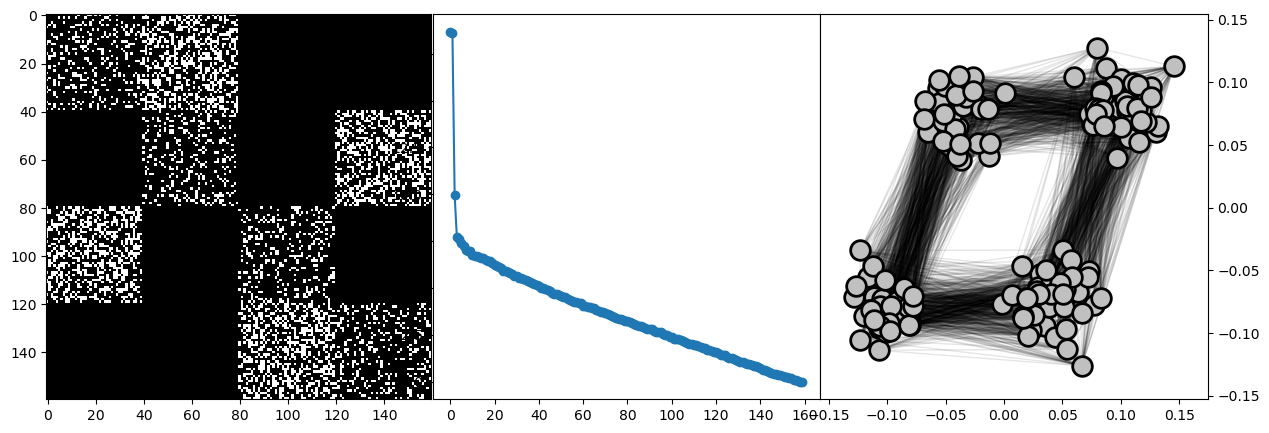

In [8]:
importlib.reload(dgsp)
importlib.reload(dgsp_plot)

def bimod_index(xout, xin, mat, norm=True):

    q_bi = xout.T @ modmat @ xin

    if norm:
        q_bi /= 2*mat.sum()

    return q_bi


vec_id = 0

seed = 28

n_per_com = 40
density_value = .4
show_n_eig = 20
fontscale = 1

graph = dgsp_graphs.toy_n_communities(n_per_com, 4, com_density=density_value,
                                      connect_density=[density_value, density_value, 0, 
                                                       0, density_value, density_value],
                                      connect_out_prob=[1, 0, 0.5, 0.5, 1, 0],
                                      seed=seed)

modmat = dgsp.modularity_matrix(graph, null_model="outin")
U, S, Vh = dgsp.sorted_SVD(modmat)
V = Vh.T

graph_pos = {i: (U[i, vec_id], V[i, vec_id]) for i in range(len(S))}

fig, axes = plt.subplots(ncols=3, figsize=(15, 5), gridspec_kw={"wspace": 0})

axes[0].imshow(graph, cmap="binary_r", vmin=0, vmax=1, interpolation="none")

print(S[-3:])
axes[1].plot(S, "o-")

axes[2].scatter(U[:, vec_id], V[:, vec_id], s=200, color="silver", edgecolors="k", lw=2, zorder=2)
_ = nx.draw_networkx_edges(nx.Graph(graph), pos=graph_pos, alpha=.1, ax=axes[2])

axes[2].tick_params(bottom="True", labelbottom="True", right="True", labelright="True")

(0.0, 0.032)

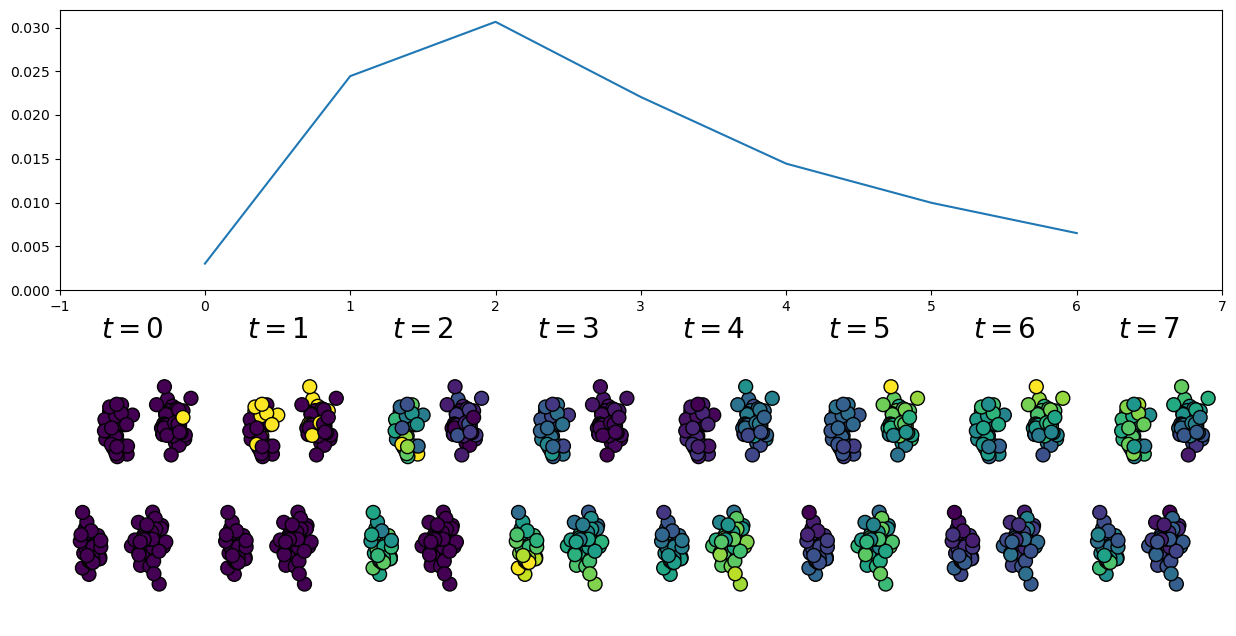

In [10]:
def autoregressor(A, x0, t=1):
    x_t = x0

    for _ in range(t):
        x_t = x_t @ A
    return x_t

n_time = 8
x0 = np.zeros(len(S))
x0[n_per_com - 2] = 1
#x0[n_per_com+2] = 1
#x0[2*n_per_com+2] = 1
#x0[3*n_per_com+2] = 1

# x0 = np.random.normal(0, 0.1, len(S))
# x0[:n_per_com] += 1

A = graph

all_qs = []
all_qs_T = []

n_show = n_time
#fig, axes = plt.subplots(nrows=2, figsize=(15, 10), gridspec_kw={"height_ratios": [2, 1]})
fig, axes = plt.subplots(nrows=2, figsize=(15, 8))

gs = GridSpecFromSubplotSpec(1, n_show, subplot_spec=axes[1].get_subplotspec(), wspace=0)
scatter_ax = [fig.add_subplot(gs[i]) for i in range(n_show)]

axes[1].axis("off")

k = 0
for t in range(n_time):
    
    #if t in [0, 20, 40]:
    if 1 :
        scatter_ax[k].scatter(U[:, vec_id], V[:, vec_id], s=100, c=x0, edgecolors="k", lw=1, zorder=2)

        scatter_ax[k].set_title(f"$t={t}$", fontsize=20)
        # scatter_ax[k].set_xticks([])
        # scatter_ax[k].set_yticks([])
        scatter_ax[k].axis("off")

        valim = 0.18
        scatter_ax[k].set_xlim(-valim, valim)
        scatter_ax[k].set_ylim(-valim, valim)

        k += 1

    x_t = autoregressor(A, x0, 1)
    x_t = x_t/x_t.max()
    #x_t = x_t/x_t.sum()

    q_bi = bimod_index(x0, x_t, graph, norm=True)
    all_qs.append(q_bi)

    x0 = x_t

axes[0].plot(np.arange(n_time-1), all_qs[:-1])
axes[0].set_xlim(-1, n_time - 1)
axes[0].set_ylim(0, 0.032)

(0.0, 0.032)

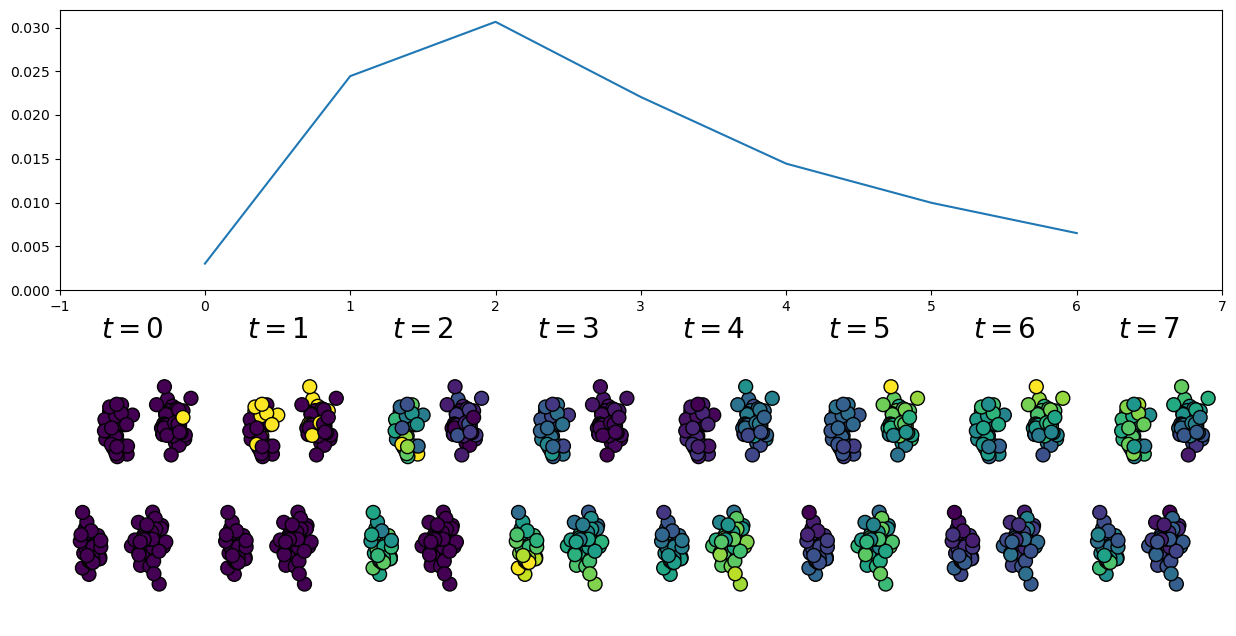

In [13]:
def autoregressor(A, x0, t=1):
    x_t = x0

    for _ in range(t):
        x_t = x_t @ A
    return x_t

n_time = 8
x0 = np.zeros(len(S))
x0[n_per_com - 2] = 1
#x0[n_per_com+2] = 1
#x0[2*n_per_com+2] = 1
#x0[3*n_per_com+2] = 1

# x0 = np.random.normal(0, 0.1, len(S))
# x0[:n_per_com] += 1

A = graph

all_qs = []
all_qs_T = []

n_show = n_time
#fig, axes = plt.subplots(nrows=2, figsize=(15, 10), gridspec_kw={"height_ratios": [2, 1]})
fig, axes = plt.subplots(nrows=2, figsize=(15, 8))

gs = GridSpecFromSubplotSpec(1, n_show, subplot_spec=axes[1].get_subplotspec(), wspace=0)
scatter_ax = [fig.add_subplot(gs[i]) for i in range(n_show)]

axes[1].axis("off")

k = 0
for t in range(n_time):
    
    #if t in [0, 20, 40]:
    if 1 :
        scatter_ax[k].scatter(U[:, vec_id], V[:, vec_id], s=100, c=x0, edgecolors="k", lw=1, zorder=2)

        scatter_ax[k].set_title(f"$t={t}$", fontsize=20)
        # scatter_ax[k].set_xticks([])
        # scatter_ax[k].set_yticks([])
        scatter_ax[k].axis("off")

        valim = 0.18
        scatter_ax[k].set_xlim(-valim, valim)
        scatter_ax[k].set_ylim(-valim, valim)

        k += 1

    x_t = autoregressor(A, x0, 1)
    x_t = x_t/x_t.max()
    #x_t = x_t/x_t.sum()

    q_bi = bimod_index(x0, x_t, graph, norm=True)
    all_qs.append(q_bi)

    x0 = x_t

axes[0].plot(np.arange(n_time-1), all_qs[:-1])
axes[0].set_xlim(-1, n_time - 1)
axes[0].set_ylim(0, 0.032)

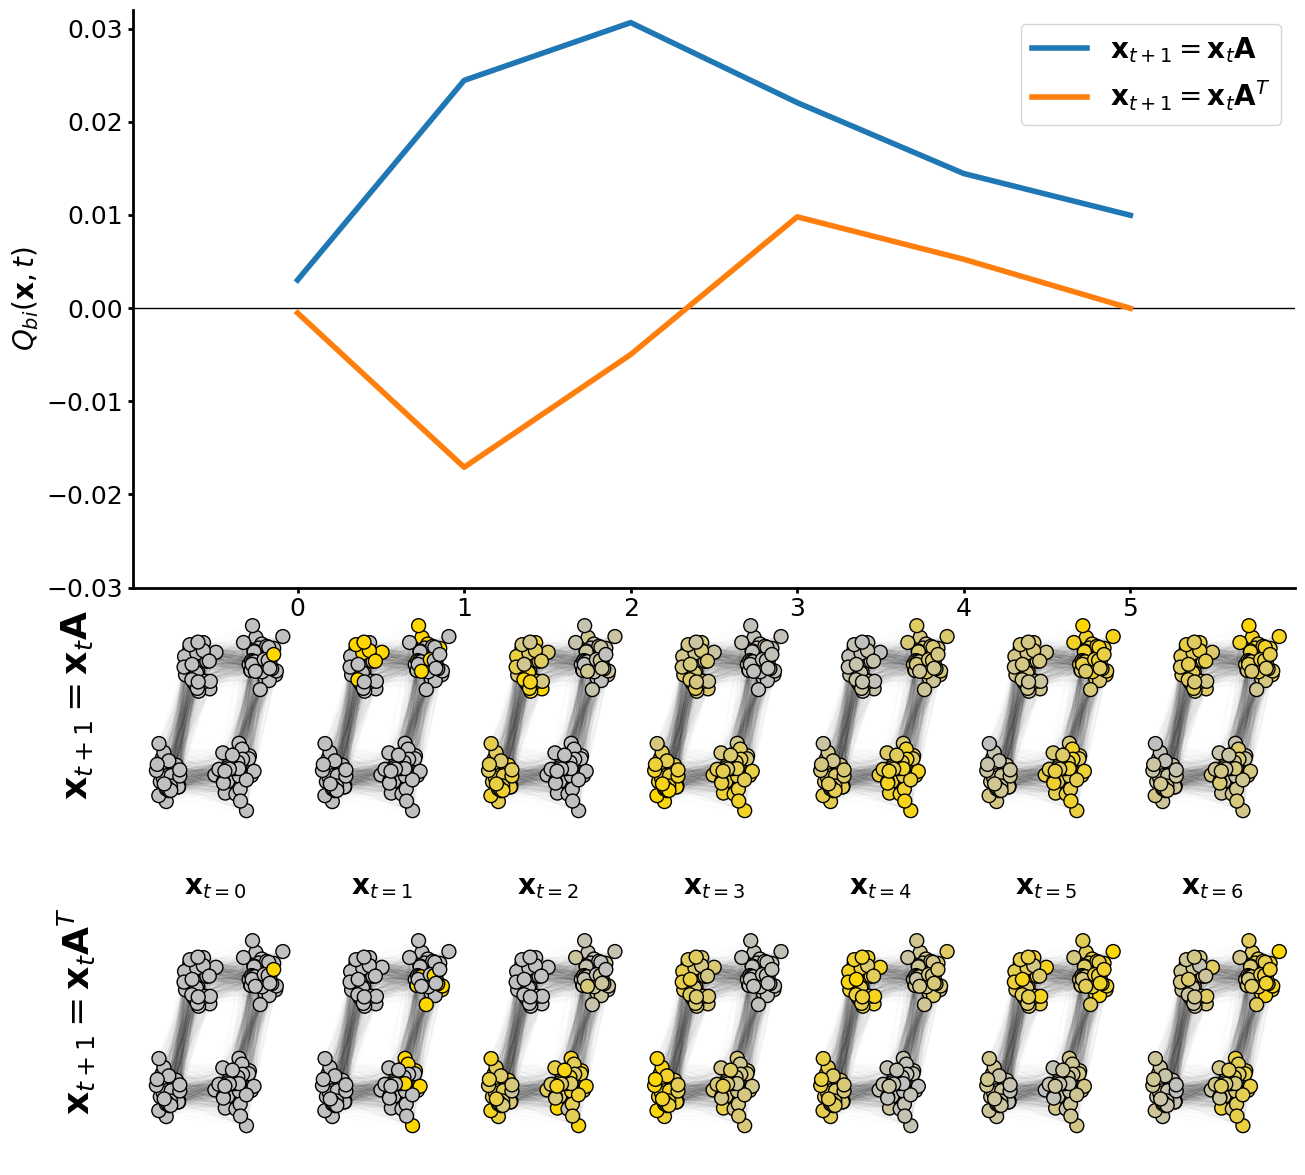

In [14]:
def autoregressor(A, x0, t=1):
    x_t = x0

    for _ in range(t):
        x_t = x_t @ A
        x_t = x_t/x_t.max()
    return x_t

n_time = 7
x0 = np.zeros(len(S))
x0[n_per_com - 2] = 1

x0_t = x0.copy()

A = graph

all_qs = []
all_qs_T = []

n_show = n_time
#fig, axes = plt.subplots(nrows=2, figsize=(15, 10), gridspec_kw={"height_ratios": [2, 1]})
fig, axes = plt.subplots(nrows=2, figsize=(15, 15), gridspec_kw={"hspace": 0})

gs = GridSpecFromSubplotSpec(2, n_show, subplot_spec=axes[1].get_subplotspec(), wspace=0)
scatter_ax = [fig.add_subplot(gs[i]) for i in range(2*n_show)]

axes[1].axis("off")

labels_k = ["$\\mathbf{{x}}_{{t+1}}=\\mathbf{{x}}_{{t}}\\mathbf{{A}}$",
            "$\\mathbf{{x}}_{{t+1}}=\\mathbf{{x}}_{{t}}\\mathbf{{A}}^{{T}}$"]

k = 0
for t in range(n_time):
    for i_trans, x_val in enumerate([x0, x0_t]):
        scatter_ax[k + i_trans*n_show].scatter(U[:, vec_id], V[:, vec_id], s=100, c=x_val, cmap=Gray2Green, edgecolors="k", lw=1, zorder=2)
        _ = nx.draw_networkx_edges(nx.Graph(graph), pos=graph_pos, alpha=.01, ax=scatter_ax[k + i_trans*n_show])

        scatter_ax[k + i_trans*n_show].axis("off")

        valim = 0.18
        scatter_ax[k + i_trans*n_show].set_xlim(-valim, valim)
        scatter_ax[k + i_trans*n_show].set_ylim(-valim, valim)

        if t == 0:
            #scatter_ax[k + i_trans*n_show].set_ylabel("$\\mathbf{{x}}_{{t+1}}=\\mathbf{{x}}_{{t}}\\mathbf{{A}}$")
            scatter_ax[k + i_trans*n_show].text(-0.3, -0.1, labels_k[i_trans], rotation=90, ha="center", fontsize=26)

    #scatter_ax[k + n_show].set_title(f"$t={t}$", fontsize=20)
    scatter_ax[k + n_show].set_title(f"$\\mathbf{{x}}_{{t={t}}}$", fontsize=20)
    k += 1

    x_t = autoregressor(A, x0, 1)
    x_t = x_t/x_t.max()
    #x_t = x_t/x_t.sum()

    q_bi = bimod_index(x0, x_t, graph, norm=True)
    all_qs.append(q_bi)
    
    q_bi_t = bimod_index(x0, autoregressor(A.T, x0, t+1), graph, norm=True)
    all_qs_T.append(q_bi_t)

    x0 = x_t
    x0_t = autoregressor(A.T, x0_t, 1)

# axes[0].plot(np.arange(n_time-1), all_qs[:-1], lw=4, label="$Q_{{bi}}(\\mathbf{{x}},t)$")
# axes[0].plot(np.arange(n_time-1), all_qs_T[:-1], lw=4, label="$Q_{{bi}}(\\mathbf{{x}},t)$ (transposed)")

axes[0].plot(np.arange(n_time-1), all_qs[:-1], lw=4, label=f"{labels_k[0]}")
axes[0].plot(np.arange(n_time-1), all_qs_T[:-1], lw=4, label=f"{labels_k[1]}")

axes[0].spines[["top", "right"]].set_visible(False)
axes[0].spines[:].set_linewidth(2)
axes[0].tick_params(width=2, labelsize=18)

axes[0].set_ylabel("$Q_{{bi}}(\\mathbf{{x}},t)$", fontsize=20)

axes[0].hlines(0, -1, n_time-1, color="k", lw=1, zorder=0)
axes[0].legend(fontsize=20)

axes[0].set_xlim(-0.99, n_time - 1.01)
axes[0].set_ylim(-0.03, 0.032)

fig.savefig(op.join(path_to_figures, f"BimodularSignal-Qbi_t{n_time}.png"), dpi=100, bbox_inches="tight")

-0.031249999999999997
0.009716386554621849
0.05278361344537815
-0.03125


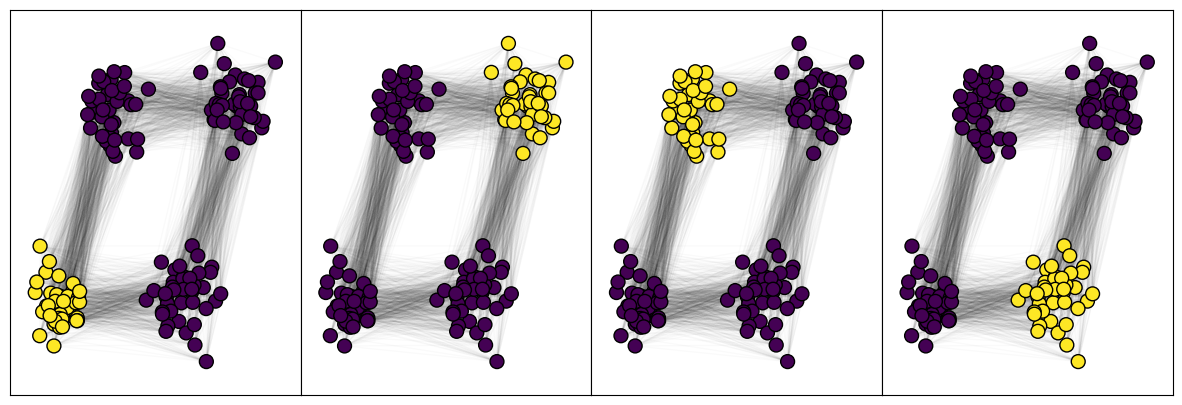

In [15]:
x0 = np.zeros(len(S))
x0[:n_per_com] = 1

xt = np.zeros(len(S))
xt[n_per_com:2*n_per_com] = 1

xopp = np.zeros(len(S))
xopp[2*n_per_com:3*n_per_com] = 1

xminus = np.zeros(len(S))
xminus[3*n_per_com:] = 1

all_vals = [xminus, x0, xt, xopp]

fig, axes = plt.subplots(ncols=len(all_vals), figsize=(15, 5), gridspec_kw={"wspace": 0})
for i, x_val in enumerate(all_vals):
    axes[i].scatter(U[:, vec_id], V[:, vec_id], s=100, c=x_val, edgecolors="k", lw=1, zorder=2)
    _ = nx.draw_networkx_edges(nx.Graph(graph), pos=graph_pos, alpha=.02, ax=axes[i])

    axes[i].set_xticks([])
    axes[i].set_yticks([])


    q_bi = bimod_index(x0, x_val, graph)
    print(q_bi)

# q_bi = bimod_index(x0, xt, graph)
# print(q_bi)

# q_bi = bimod_index(x0, x0, graph)
# print(q_bi)

/var/folders/nj/ltrlv15x5jj2jq78pbb2srz80000gn/T/ipykernel_46306/2900833318.py:42: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  axes[2].scatter(U[:, vec_id], V[:, vec_id], s=70, color="silver", edgecolors="k", lw=1, zorder=2, vmin=-1, vmax=1)
/var/folders/nj/ltrlv15x5jj2jq78pbb2srz80000gn/T/ipykernel_46306/2900833318.py:47: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  axes[3].scatter(U[:, vec_id], V[:, vec_id], s=70, color="silver", edgecolors="k", lw=1, zorder=2, vmin=-1, vmax=1)


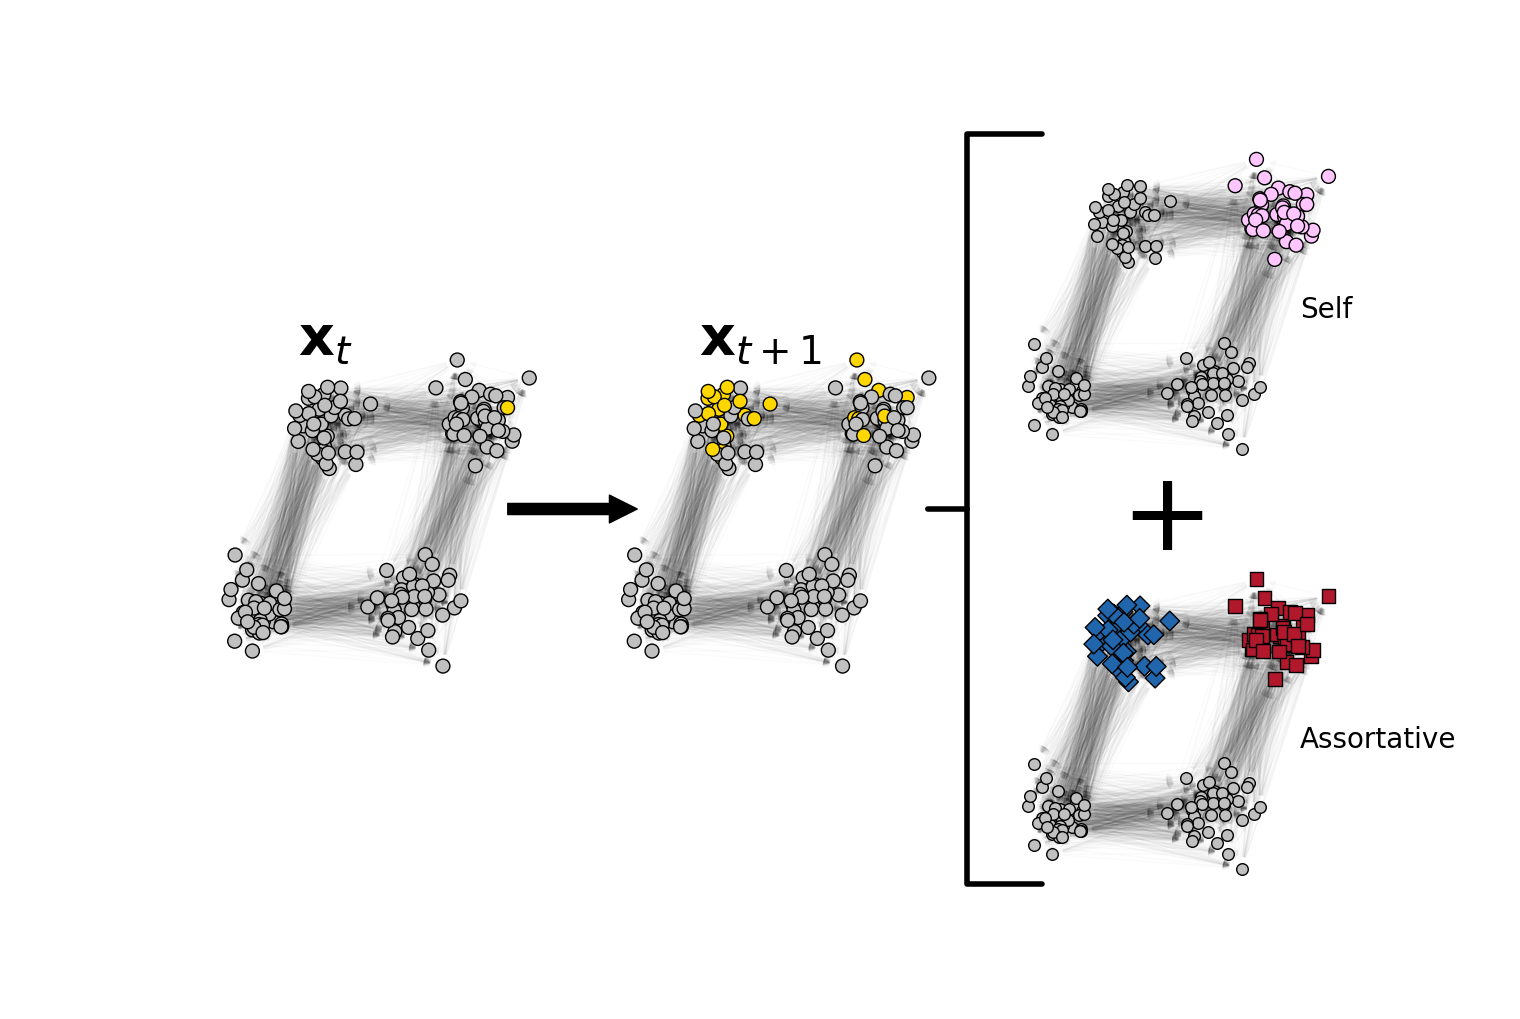

In [17]:
fig, all_ax = plt.subplots(ncols=3, figsize=(15, 10), gridspec_kw={"wspace": 0.1})
#fig, axes = plt.subplots(ncols=3, figsize=(15, 10), gridspec_kw={"wspace": 0, "width_ratios": [2, 2, 1]})

gs = GridSpecFromSubplotSpec(2, 1, subplot_spec=all_ax[-1].get_subplotspec())
axes = [all_ax[0], all_ax[1]] + [fig.add_subplot(gs[i]) for i in range(2)]
all_ax[-1].axis("off")  

x0 = np.zeros(len(S))
xt = x0.copy()

#x0[:n_per_com] = 1
#xt[n_per_com:2*n_per_com] = 1

x0[n_per_com - 2] = 1
xt = autoregressor(graph, x0)

bicom0 = np.zeros(len(S))
bicom0[n_per_com:] = -1

bicom1 = np.zeros(len(S))
bicom1[:n_per_com] = 1
bicom1[n_per_com:2*n_per_com] = -1

all_vals = [x0, xt]
all_bicom = [bicom0]

directed = True
if directed:
    nx_graph = nx.DiGraph(graph)
else:
    nx_graph = nx.Graph(graph)

for i, x_val in enumerate(all_vals):
    axes[i].scatter(U[:, vec_id], V[:, vec_id], s=100, c=x_val, cmap=Gray2Green, edgecolors="k", lw=1, zorder=2)
    _ = nx.draw_networkx_edges(nx_graph, pos=graph_pos, alpha=.02, ax=axes[i])

    axes[i].axis("off")
    
    limit = V[:, vec_id].max()*2.5
    axes[i].set_ylim(-limit, limit)

axes[2].scatter(U[:, vec_id], V[:, vec_id], s=70, color="silver", edgecolors="k", lw=1, zorder=2, vmin=-1, vmax=1)
axes[2].scatter(U[bicom0 == 0, vec_id], V[bicom0 == 0, vec_id], s=100, c=bicom0[bicom0 == 0], cmap=RedPurpleBlue, edgecolors="k", lw=1, zorder=2, vmin=-1, vmax=1)
_ = nx.draw_networkx_edges(nx_graph, pos=graph_pos, alpha=.02, ax=axes[2])
axes[2].axis("off")

axes[3].scatter(U[:, vec_id], V[:, vec_id], s=70, color="silver", edgecolors="k", lw=1, zorder=2, vmin=-1, vmax=1)
axes[3].scatter(U[bicom1 > 0, vec_id], V[bicom1 > 0, vec_id], s=100, c=bicom1[bicom1 > 0], cmap=RedPurpleBlue, edgecolors="k", lw=1, zorder=2, marker="s", vmin=-1, vmax=1)
axes[3].scatter(U[bicom1 < 0, vec_id], V[bicom1 < 0, vec_id], s=100, c=bicom1[bicom1 < 0], cmap=RedPurpleBlue, edgecolors="k", lw=1, zorder=2, marker="D", vmin=-1, vmax=1)
_ = nx.draw_networkx_edges(nx_graph, pos=graph_pos, alpha=.02, ax=axes[3])
axes[3].axis("off")

#bracket = ArrowStyle("-[")
fig.add_artist(FancyArrowPatch((0.61, 0.5), (0.64, 0.5), arrowstyle="-[", mutation_scale=270, lw=4, color="k"))
fig.add_artist(FancyArrowPatch((0.33, 0.5), (0.42, 0.5), arrowstyle="simple", mutation_scale=40, lw=1, color="k"))
ax_text = fig.add_subplot([0, 0, 1, 1], facecolor="none")
ax_text.axis("off")

ax_text.text(0.74, 0.46, "+", fontsize=80)

ax_text.text(0.21, 0.67, "$\\mathbf{x}_{{t}}$", fontsize=40, ha="center", va="center")
ax_text.text(0.5, 0.67, "$\\mathbf{x}_{{t+1}}$", fontsize=40, ha="center", va="center")

ax_text.text(0.86, 0.7, "Self", fontsize=20, ha="left", va="center")
ax_text.text(0.86, 0.27, "Assortative", fontsize=20, ha="left", va="center")

fig.savefig(op.join(path_to_figures, f"BimodularSignal-Example{'-dir'*directed}.png"), dpi=100, bbox_inches="tight")

/var/folders/nj/ltrlv15x5jj2jq78pbb2srz80000gn/T/ipykernel_46306/1101373191.py:37: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  axes[2].scatter(U[:, vec_id], V[:, vec_id], s=70, color="silver", edgecolors="k", lw=1, zorder=2, vmin=-1, vmax=1)
/var/folders/nj/ltrlv15x5jj2jq78pbb2srz80000gn/T/ipykernel_46306/1101373191.py:42: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  axes[3].scatter(U[:, vec_id], V[:, vec_id], s=70, color="silver", edgecolors="k", lw=1, zorder=2, vmin=-1, vmax=1)


Text(0, 0.15, 'Assortative')

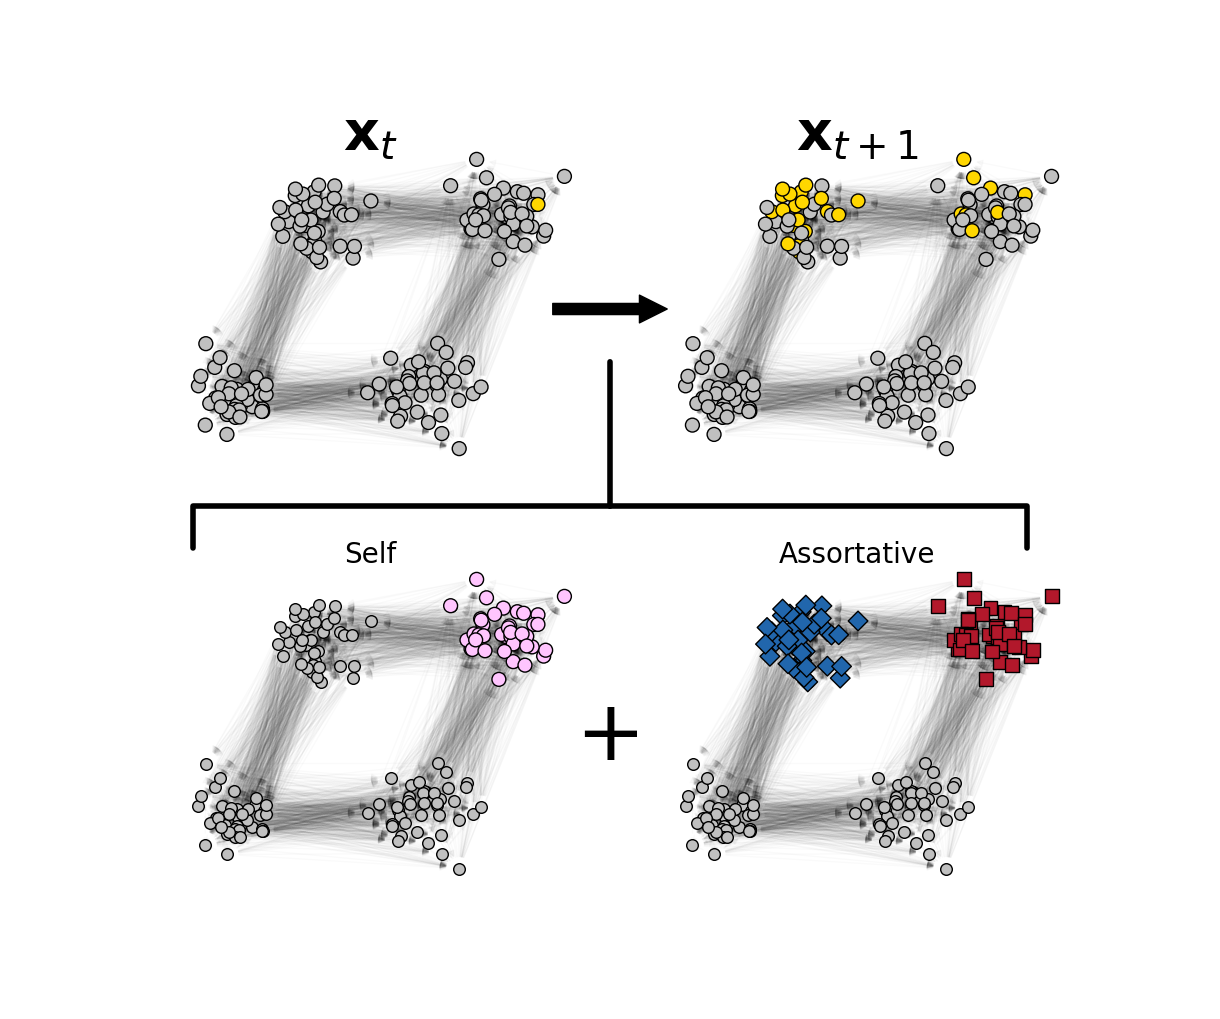

In [18]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10), gridspec_kw={"wspace": 0.1})
#fig, axes = plt.subplots(ncols=3, figsize=(15, 10), gridspec_kw={"wspace": 0, "width_ratios": [2, 2, 1]})

axes = axes.flatten()

x0 = np.zeros(len(S))
xt = x0.copy()

#x0[:n_per_com] = 1
#xt[n_per_com:2*n_per_com] = 1

x0[n_per_com - 2] = 1
xt = autoregressor(graph, x0)

bicom0 = np.zeros(len(S))
bicom0[n_per_com:] = -1

bicom1 = np.zeros(len(S))
bicom1[:n_per_com] = 1
bicom1[n_per_com:2*n_per_com] = -1

all_vals = [x0, xt]
all_bicom = [bicom0]

directed = True
if directed:
    nx_graph = nx.DiGraph(graph)
else:
    nx_graph = nx.Graph(graph)

for i, x_val in enumerate(all_vals):
    axes[i].scatter(U[:, vec_id], V[:, vec_id], s=100, c=x_val, cmap=Gray2Green, edgecolors="k", lw=1, zorder=2)
    _ = nx.draw_networkx_edges(nx_graph, pos=graph_pos, alpha=.02, ax=axes[i])

    axes[i].axis("off")

axes[2].scatter(U[:, vec_id], V[:, vec_id], s=70, color="silver", edgecolors="k", lw=1, zorder=2, vmin=-1, vmax=1)
axes[2].scatter(U[bicom0 == 0, vec_id], V[bicom0 == 0, vec_id], s=100, c=bicom0[bicom0 == 0], cmap=RedPurpleBlue, edgecolors="k", lw=1, zorder=2, vmin=-1, vmax=1)
_ = nx.draw_networkx_edges(nx_graph, pos=graph_pos, alpha=.02, ax=axes[2])
axes[2].axis("off")

axes[3].scatter(U[:, vec_id], V[:, vec_id], s=70, color="silver", edgecolors="k", lw=1, zorder=2, vmin=-1, vmax=1)
axes[3].scatter(U[bicom1 > 0, vec_id], V[bicom1 > 0, vec_id], s=100, c=bicom1[bicom1 > 0], cmap=RedPurpleBlue, edgecolors="k", lw=1, zorder=2, marker="s", vmin=-1, vmax=1)
axes[3].scatter(U[bicom1 < 0, vec_id], V[bicom1 < 0, vec_id], s=100, c=bicom1[bicom1 < 0], cmap=RedPurpleBlue, edgecolors="k", lw=1, zorder=2, marker="D", vmin=-1, vmax=1)
_ = nx.draw_networkx_edges(nx_graph, pos=graph_pos, alpha=.02, ax=axes[3])
axes[3].axis("off")

#fig.add_artist(FancyArrowPatch((0.5, 0.6), (0.5, 0.53), arrowstyle="-[", mutation_scale=200, lw=4, color="k"))
fig.add_artist(FancyArrowPatch((0.5, 0.65), (0.5, 0.5), arrowstyle=ArrowStyle("-[", widthB=300, lengthB=30), lw=4, color="k"))
fig.add_artist(FancyArrowPatch((0.45, 0.7), (0.55, 0.7), arrowstyle="simple", mutation_scale=40, lw=1, color="k"))
ax_text = fig.add_subplot([0, 0, 1, 1], facecolor="none")
ax_text.axis("off")

ax_text.text(0.5, 0.25, "+", fontsize=60, ha="center")

axes[0].text(0, 0.15, "$\\mathbf{x}_{{t}}$", fontsize=40, ha="center", va="center")
axes[1].text(0, 0.15, "$\\mathbf{x}_{{t+1}}$", fontsize=40, ha="center", va="center")

axes[2].text(0, 0.15, "Self", fontsize=20, ha="center", va="center")
axes[3].text(0, 0.15, "Assortative", fontsize=20, ha="center", va="center")

#fig.savefig(op.join(path_to_figures, f"BimodularSignal-Example{'-dir'*directed}.png"), dpi=100, bbox_inches="tight")

/var/folders/nj/ltrlv15x5jj2jq78pbb2srz80000gn/T/ipykernel_46306/208447416.py:43: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  axes[1].scatter(U[:, vec_id], V[:, vec_id], s=70, color="silver", edgecolors="k", lw=1, zorder=2, vmin=-1, vmax=1)
/var/folders/nj/ltrlv15x5jj2jq78pbb2srz80000gn/T/ipykernel_46306/208447416.py:48: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  axes[3].scatter(U[:, vec_id], V[:, vec_id], s=70, color="silver", edgecolors="k", lw=1, zorder=2, vmin=-1, vmax=1)
/var/folders/nj/ltrlv15x5jj2jq78pbb2srz80000gn/T/ipykernel_46306/208447416.py:53: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  axes[2].scatter(U[:, vec_id], V[:, vec_id], s=70, color="silver", edgecolors="k", lw=1, zorder=2, vmin=-1, vmax=1)


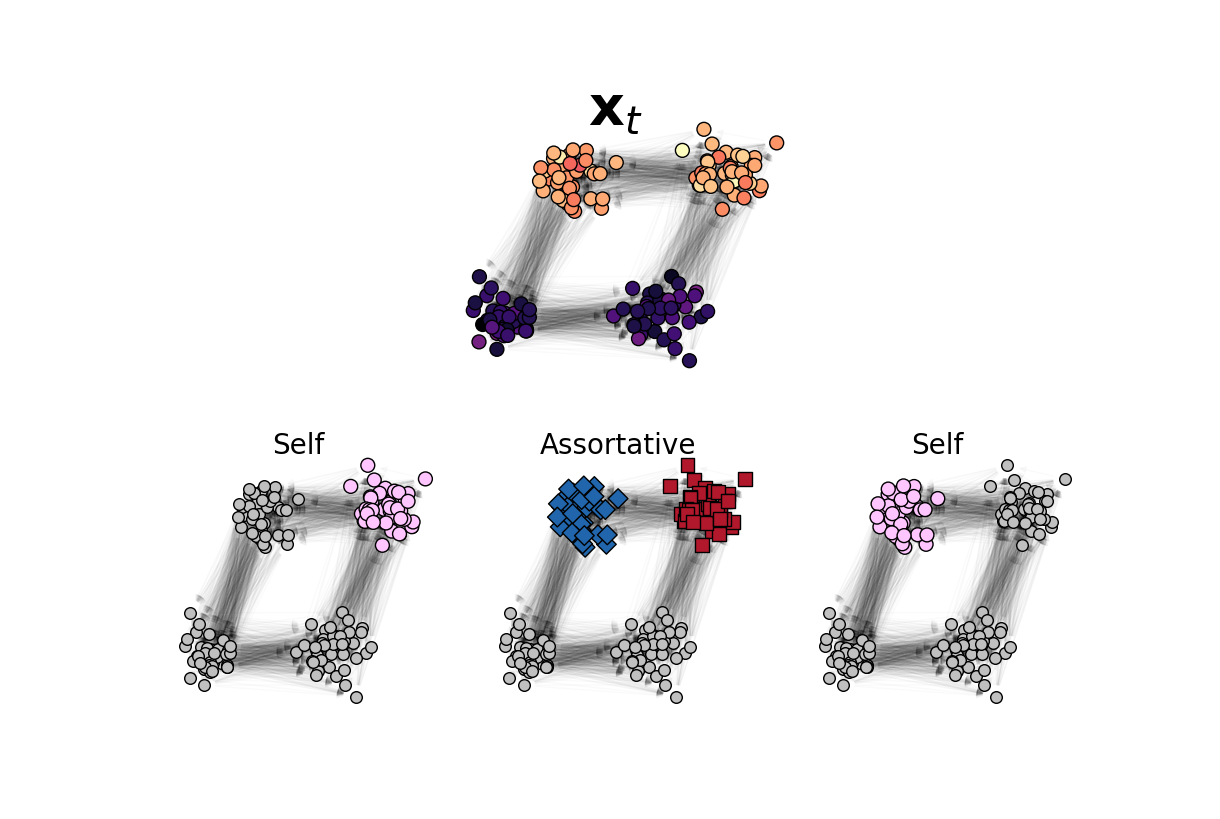

In [19]:
fig, all_axes = plt.subplots(nrows=2, figsize=(12, 8), height_ratios=[1, 1])
#fig, axes = plt.subplots(ncols=3, figsize=(15, 10), gridspec_kw={"wspace": 0, "width_ratios": [2, 2, 1]})

gs = GridSpecFromSubplotSpec(1, 3, subplot_spec=all_axes[1].get_subplotspec(), wspace=0.1)
gs_solo = GridSpecFromSubplotSpec(1, 3, subplot_spec=all_axes[0].get_subplotspec(), wspace=0.4, width_ratios=[1, 2, 1])
#axes = [all_axes[0]] + [fig.add_subplot(gs[i]) for i in range(2)]

axes = [fig.add_subplot(gs_solo[1])] + [fig.add_subplot(gs[i]) for i in range(3)]

all_axes[0].axis("off")
all_axes[1].axis("off")

xt = np.random.normal(0, 0.1, len(x0))
xt[:2*n_per_com] += 1

bicom0 = np.zeros(len(S))
bicom0[n_per_com:] = -1

bicom2 = np.zeros(len(S))
bicom2[:n_per_com] = -1
bicom2[2*n_per_com:] = -1

bicom1 = np.zeros(len(S))
bicom1[:n_per_com] = 1
bicom1[n_per_com:2*n_per_com] = -1

all_vals = [xt]
all_bicom = [bicom0]

directed = True
if directed:
    nx_graph = nx.DiGraph(graph)
else:
    nx_graph = nx.Graph(graph)

for i, x_val in enumerate(all_vals):
    #axes[i].scatter(U[:, vec_id], V[:, vec_id], s=100, c=x_val, cmap=Gray2Green, edgecolors="k", lw=1, zorder=2)
    axes[i].scatter(U[:, vec_id], V[:, vec_id], s=100, c=x_val, cmap="magma", edgecolors="k", lw=1, zorder=2)
    _ = nx.draw_networkx_edges(nx_graph, pos=graph_pos, alpha=.02, ax=axes[i])

    axes[i].axis("off")

axes[1].scatter(U[:, vec_id], V[:, vec_id], s=70, color="silver", edgecolors="k", lw=1, zorder=2, vmin=-1, vmax=1)
axes[1].scatter(U[bicom0 == 0, vec_id], V[bicom0 == 0, vec_id], s=100, c=bicom0[bicom0 == 0], cmap=RedPurpleBlue, edgecolors="k", lw=1, zorder=2, vmin=-1, vmax=1)
_ = nx.draw_networkx_edges(nx_graph, pos=graph_pos, alpha=.02, ax=axes[1])
axes[1].axis("off")

axes[3].scatter(U[:, vec_id], V[:, vec_id], s=70, color="silver", edgecolors="k", lw=1, zorder=2, vmin=-1, vmax=1)
axes[3].scatter(U[bicom2 == 0, vec_id], V[bicom2 == 0, vec_id], s=100, c=bicom2[bicom2 == 0], cmap=RedPurpleBlue, edgecolors="k", lw=1, zorder=2, vmin=-1, vmax=1)
_ = nx.draw_networkx_edges(nx_graph, pos=graph_pos, alpha=.02, ax=axes[3])
axes[3].axis("off")

axes[2].scatter(U[:, vec_id], V[:, vec_id], s=70, color="silver", edgecolors="k", lw=1, zorder=2, vmin=-1, vmax=1)
axes[2].scatter(U[bicom1 > 0, vec_id], V[bicom1 > 0, vec_id], s=100, c=bicom1[bicom1 > 0], cmap=RedPurpleBlue, edgecolors="k", lw=1, zorder=2, marker="s", vmin=-1, vmax=1)
axes[2].scatter(U[bicom1 < 0, vec_id], V[bicom1 < 0, vec_id], s=100, c=bicom1[bicom1 < 0], cmap=RedPurpleBlue, edgecolors="k", lw=1, zorder=2, marker="D", vmin=-1, vmax=1)
_ = nx.draw_networkx_edges(nx_graph, pos=graph_pos, alpha=.02, ax=axes[2])
axes[2].axis("off")

#fig.add_artist(FancyArrowPatch((0.5, 0.6), (0.5, 0.53), arrowstyle="-[", mutation_scale=200, lw=4, color="k"))
#fig.add_artist(FancyArrowPatch((0.5, 0.55), (0.5, 0.5), arrowstyle=ArrowStyle("-[", widthB=300, lengthB=30), lw=4, color="k"))
#fig.add_artist(FancyArrowPatch((0.45, 0.7), (0.55, 0.7), arrowstyle="simple", mutation_scale=40, lw=1, color="k"))
ax_text = fig.add_subplot([0, 0, 1, 1], facecolor="none")
ax_text.axis("off")

#ax_text.text(0.5, 0.25, "+", fontsize=60, ha="center")

axes[0].text(0, 0.15, "$\\mathbf{x}_{{t}}$", fontsize=40, ha="center", va="center")
#axes[1].text(0, 0.15, "$\\mathbf{x}_{{t+1}}$", fontsize=40, ha="center", va="center")

axes[3].text(0, 0.15, "Self", fontsize=20, ha="center", va="center")
axes[1].text(0, 0.15, "Self", fontsize=20, ha="center", va="center")
axes[2].text(0, 0.15, "Assortative", fontsize=20, ha="center", va="center")

fig.savefig(op.join(path_to_figures, f"BimodularSignals-PREZ{'-dir'*directed}.png"), dpi=300, bbox_inches="tight")

/var/folders/nj/ltrlv15x5jj2jq78pbb2srz80000gn/T/ipykernel_46306/524277571.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  axes.scatter(U[:, vec_id], V[:, vec_id], s=70, color="silver", edgecolors="k", lw=1, zorder=2, vmin=-1, vmax=1)


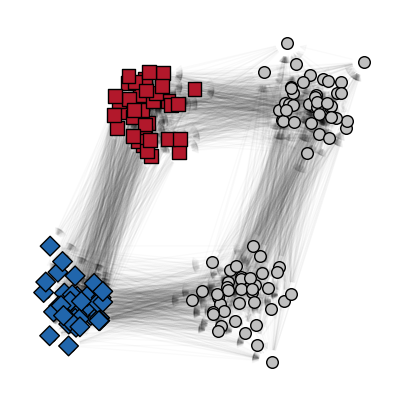

In [20]:
fig, axes = plt.subplots(figsize=(5, 5))

bicom1 = np.zeros(len(S))
bicom1[n_per_com:2*n_per_com] = 1
bicom1[3*n_per_com:] = -1

directed = True
if directed:
    nx_graph = nx.DiGraph(graph)
else:
    nx_graph = nx.Graph(graph)

axes.scatter(U[:, vec_id], V[:, vec_id], s=70, color="silver", edgecolors="k", lw=1, zorder=2, vmin=-1, vmax=1)
axes.scatter(U[bicom1 > 0, vec_id], V[bicom1 > 0, vec_id], s=100, c=bicom1[bicom1 > 0], cmap=RedPurpleBlue, edgecolors="k", lw=1, zorder=2, marker="s", vmin=-1, vmax=1)
axes.scatter(U[bicom1 < 0, vec_id], V[bicom1 < 0, vec_id], s=100, c=bicom1[bicom1 < 0], cmap=RedPurpleBlue, edgecolors="k", lw=1, zorder=2, marker="D", vmin=-1, vmax=1)
_ = nx.draw_networkx_edges(nx_graph, pos=graph_pos, alpha=.02, ax=axes)
axes.axis("off")

fig.savefig(op.join(path_to_figures, f"ResearchOutputs{'-dir'*directed}.png"), dpi=300, bbox_inches="tight")

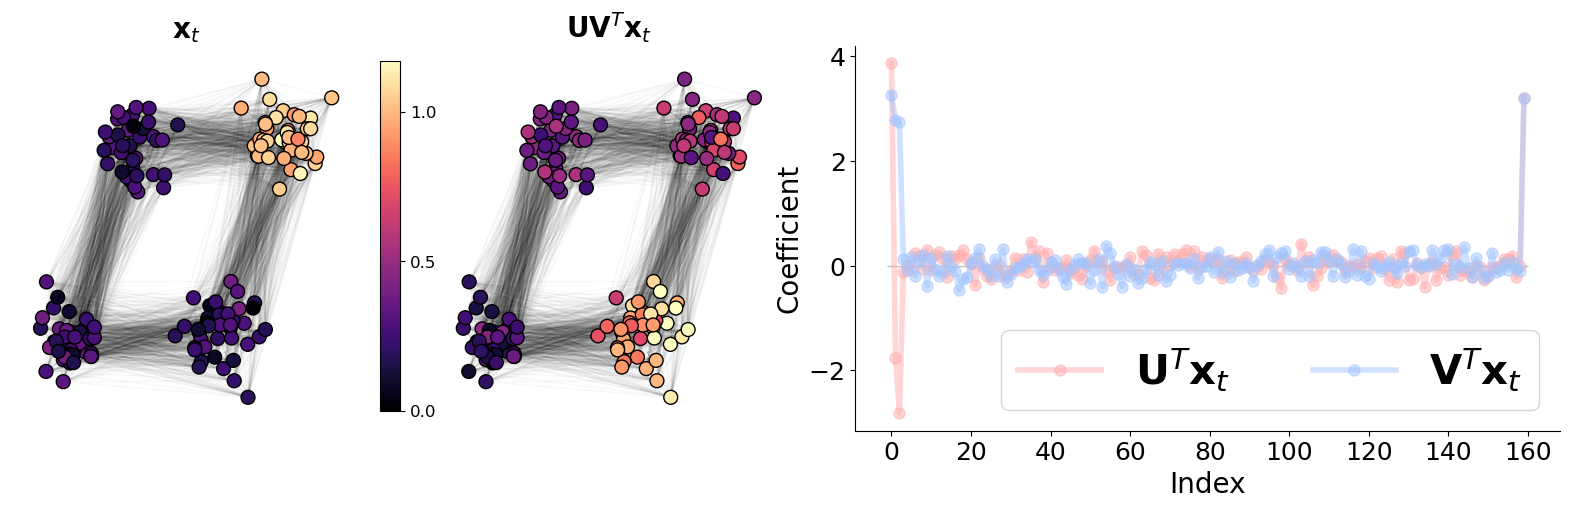

In [21]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


fig, axes = plt.subplots(ncols=3, figsize=(20, 5), gridspec_kw={"width_ratios": [1, 1, 2], "wspace":0.15})

x0 = np.zeros(len(S))
xt = x0.copy()

x0[n_per_com - 2] = 1
#x0[4*n_per_com - 2] = 1
xt = autoregressor(graph, x0, 1)

x0 = xt.copy()
xt = autoregressor(graph, x0, 1)

# xt = np.arange(len(x0))
# xt[2*n_per_com:3*n_per_com] = np.arange(len(x0))[3*n_per_com:4*n_per_com]
# xt[3*n_per_com:4*n_per_com] = np.arange(len(x0))[2*n_per_com:3*n_per_com]

xt = np.random.normal(0, 0.1, len(x0))
xt[:n_per_com] += 1
#xt[:2*n_per_com] += 1

# x0 = U[:, vec_id]
# xt = V[:, vec_id]

axes[0].set_title(f"$\\mathbf{{x}}_{{t}}$", fontsize=20)
#axes[0].scatter(U[:, vec_id], V[:, vec_id], s=100, c=xt, cmap=Gray2Green, edgecolors="k", lw=1, zorder=2, vmin=0, vmax=1)
axes[0].scatter(U[:, vec_id], V[:, vec_id], s=100, c=xt, cmap="magma", edgecolors="k", lw=1, zorder=2, vmax=xt.max())
#axes[0].scatter(U[n_per_com - 2, vec_id], V[n_per_com - 2, vec_id], s=100, color="r", edgecolors="k", marker="s", lw=1, zorder=2)
#axes[0].scatter(U[:, vec_id], V[:, vec_id], s=100, c=U[:, 0], cmap="coolwarm", edgecolors="k", lw=1, zorder=2)
nx.draw_networkx_edges(nx.Graph(graph), pos=graph_pos, alpha=.03, ax=axes[0])

cutoff = len(V)//4
cutoff = 160

fourier = V.T @ xt
fourier[cutoff:] = 0

#reconstruted_sig = V @ fourier
reconstruted_sig = U @ fourier

#reconstruted_sig = V[0]

axes[1].set_title(f"$\\mathbf{{U}}\\mathbf{{V}}^T\\mathbf{{x}}_{{t}}$", fontsize=20)
#axes[1].scatter(U[:, vec_id], V[:, vec_id], s=100, c=reconstruted_sig, cmap=Gray2Green, edgecolors="k", lw=1, zorder=2)#, vmin=0, vmax=1)
axes[1].scatter(U[:, vec_id], V[:, vec_id], s=100, c=reconstruted_sig, cmap="magma", edgecolors="k", lw=1, zorder=2, vmax=xt.max())#, vmin=0, vmax=1)
# axes[1].scatter(U[:, vec_id], V[:, vec_id], s=100, c=U[:, -1], cmap="coolwarm", edgecolors="k", lw=1, zorder=2)
nx.draw_networkx_edges(nx.Graph(graph), pos=graph_pos, alpha=.03, ax=axes[1])

#axes[2].plot(S/5, marker="o", markersize=5, label="$\\sigma$")

axes[2].plot(np.linalg.inv(U) @ xt, marker="o", color=palette_rgb[0], lw=4, markersize=8, alpha=0.5, label="$\\mathbf{U}^{{T}}\\mathbf{{x}}_{{t}}$")
axes[2].plot(np.linalg.inv(V) @ xt, marker="o", color=palette_rgb[1], lw=4, markersize=8, alpha=0.5, label="$\\mathbf{V}^{{T}}\\mathbf{{x}}_{{t}}$")

#axes[2].plot(np.linalg.inv(U) @ xt, ls=":", marker="o", markersize=5, label="$\\mathbf{U}^{{-1}}x_{{2}}$")
#axes[2].plot(np.linalg.inv(V) @ x0, ls=":", label="$\\mathbf{V}^{{-1}}x_{{1}}$")

axes[2].hlines(0, xmin=-1, xmax=len(x0), color="silver", lw=1, zorder=0)

#axes[2].set_xlim(-1, 13)
axes[2].legend(ncol=3, fontsize=30)

for ax in [axes[0], axes[1]]:
    ax.spines[:].set_visible(False)

axes[2].spines[["top", "right"]].set_visible(False)
#axes[2].set_xlim(-1, 8.9)

axes[2].set_xlabel("Index", fontsize=20)
axes[2].set_ylabel("Coefficient", fontsize=20)
axes[2].tick_params(labelsize=18)

cmap_ax = fig.add_axes([0.31, 0.15, 0.01, 0.7])

norm = Normalize(vmin=0, vmax=xt.max())
cbar = fig.colorbar(
            ScalarMappable(norm=norm, cmap="magma"),
            cax=cmap_ax,
            orientation="vertical",
            ticks=np.linspace(0, np.ceil(xt.max()), 5),
        )
cbar.ax.tick_params(labelsize=12)

#fig.savefig(op.join(path_to_figures, f"FourierSignal-Example.png"), dpi=400, bbox_inches="tight")

/var/folders/nj/ltrlv15x5jj2jq78pbb2srz80000gn/T/ipykernel_46306/489118261.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmax' will be ignored
  axes[1].scatter(U[:, vec], V[:, vec], s=100, color="tab:blue", edgecolors="k", lw=1, zorder=2, vmax=xt.max())#, vmin=0, vmax=1)


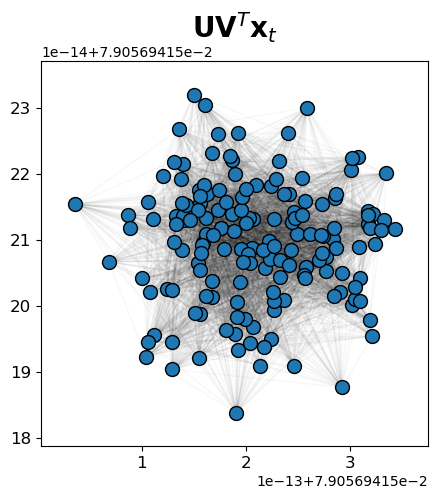

In [22]:
fig, axes = plt.subplots(figsize=(5, 5))

axes = [axes]*2

vec = -1

axes[1].set_title(f"$\\mathbf{{U}}\\mathbf{{V}}^T\\mathbf{{x}}_{{t}}$", fontsize=20)
#axes[1].scatter(U[:, vec_id], V[:, vec_id], s=100, c=reconstruted_sig, cmap=Gray2Green, edgecolors="k", lw=1, zorder=2)#, vmin=0, vmax=1)
axes[1].scatter(U[:, vec], V[:, vec], s=100, color="tab:blue", edgecolors="k", lw=1, zorder=2, vmax=xt.max())#, vmin=0, vmax=1)

graph_pos = {i: (U[i, vec], V[i, vec]) for i in range(len(S))}
nx.draw_networkx_edges(nx.Graph(graph), pos=graph_pos, alpha=.03, ax=axes[1])

axes[0].tick_params(left=True, labelleft=True, bottom=True, labelbottom=True, labelsize=12)

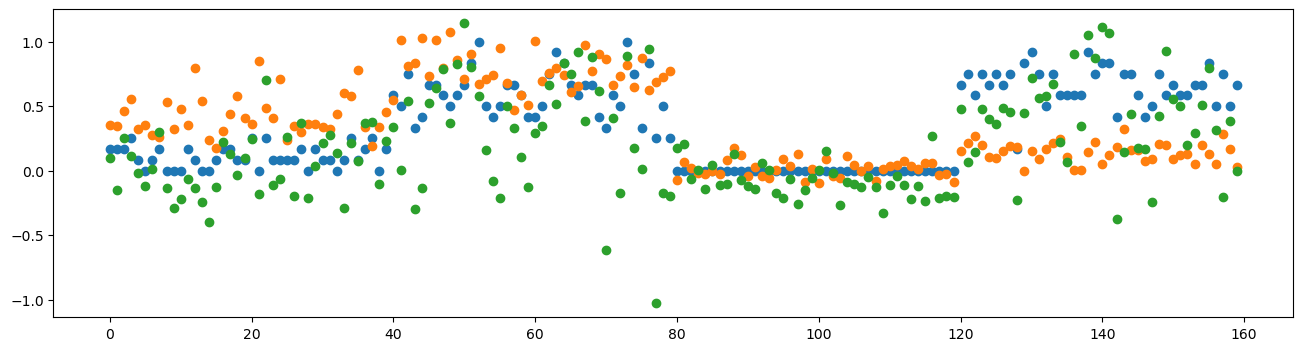

In [23]:
fig, axes = plt.subplots(figsize=(16, 4))

x0 = np.zeros(len(S))
xt = x0.copy()

x0[n_per_com - 2] = 1
#x0[4*n_per_com - 2] = 1
xt = autoregressor(graph, x0, 1)
x0 = xt.copy()

xt = autoregressor(graph, x0, 1)

axes.scatter(np.arange(len(xt)), xt)

cutoff = 165

fourier = V.T @ xt
fourier[cutoff:] = 0
reconstruted_sig = U @ fourier

# print(fourier[:cutoff])
axes.scatter(np.arange(len(xt)), reconstruted_sig)

fourier = U.T @ x0
fourier[cutoff:] = 0
reconstruted_sig = V @ fourier

# print(fourier[:cutoff])
axes.scatter(np.arange(len(xt)), reconstruted_sig)

(160, 2)


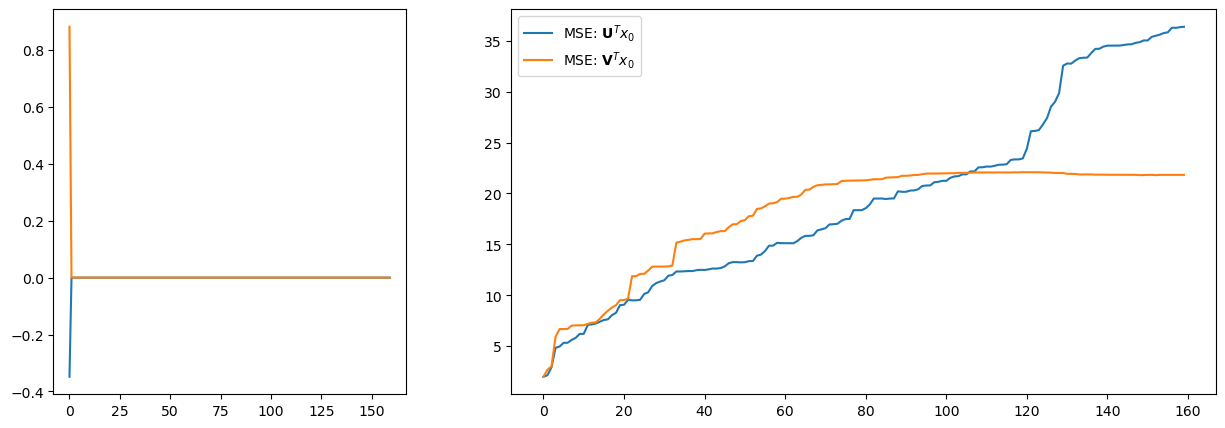

In [24]:
fig, axes = plt.subplots(ncols=2, figsize=(15, 5), width_ratios=[1, 2])

x0 = np.zeros(len(S))
xt = x0.copy()

x0[n_per_com - 2] = 1
x0[4*n_per_com - 2] = 1
xt = autoregressor(graph, x0, 1)

all_sig = []
for cutoff in range(len(V)):
    for sig in [xt]:
        for vec in [U, V]:
        
            #V_thresh[cutoff:] = 0

            mask = np.ones(len(S))
            mask[cutoff:] = 0

            fourier = vec.T @ sig
            fourier[cutoff:] = 0
            reconstruted_sig = U @ fourier
            #all_sig.append(((sig - reconstruted_sig)**2).sum())
            all_sig.append(((x0 - reconstruted_sig)**2).sum())

            if cutoff == 1:
                axes[0].plot(fourier*mask)

all_sig = np.array(all_sig).reshape((-1, 2))
print(all_sig.shape)

axes[1].plot(all_sig)
# axes[1].plot(np.array(all_sig), label="MSE: $\\mathbf{{V}}^T x$")
# axes[1].plot(np.array(all_sig_U), label="MSE: $\\mathbf{{U}}^T x$")

axes[1].legend([f"MSE: $\\mathbf{{{vec}}}^T {sig}$" for sig in ["x_{{0}}", "x_{{1}}"] for vec in ["U", "V"]])

Text(0, 0.5, '')

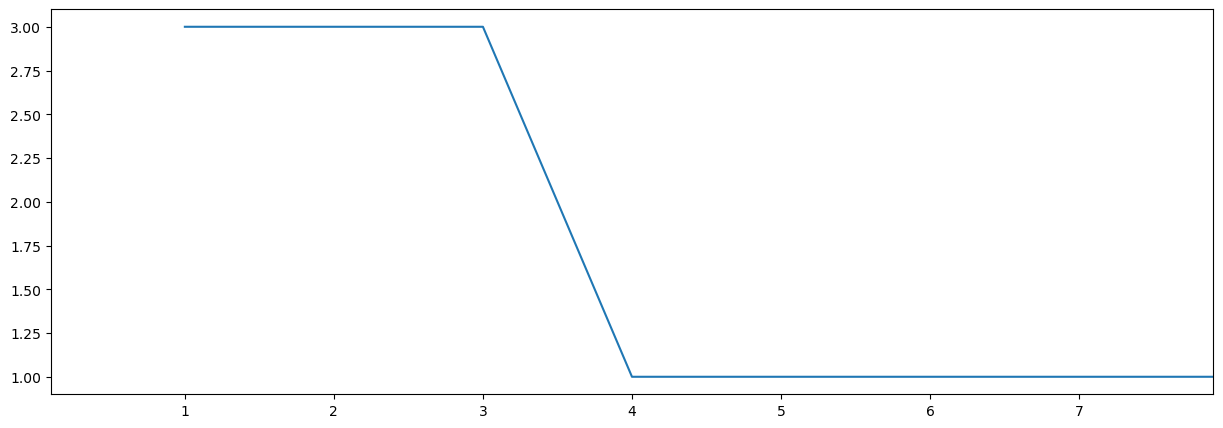

In [25]:
fig, axes = plt.subplots(figsize=(15, 5))

x0 = np.zeros(len(S))
xt = x0.copy()

x0[n_per_com - 2] = 1
x0[4*n_per_com - 2] = 1
xt = autoregressor(graph, x0, 1)

all_sig = []
for cutoff in range(1, len(V)):

    fourier = V.T @ xt
    fourier[cutoff:] = 0
    reconstruted_sig = U @ fourier
    #all_sig.append(((sig - reconstruted_sig)**2).sum())

    all_sig.append(((x0 - (reconstruted_sig == reconstruted_sig.max()))**2).sum())

axes.plot(range(1, len(V)), all_sig)

axes.set_xlim(0.1, 7.9)

axes.set_xlabel("")
axes.set_ylabel("")

## Edge representation

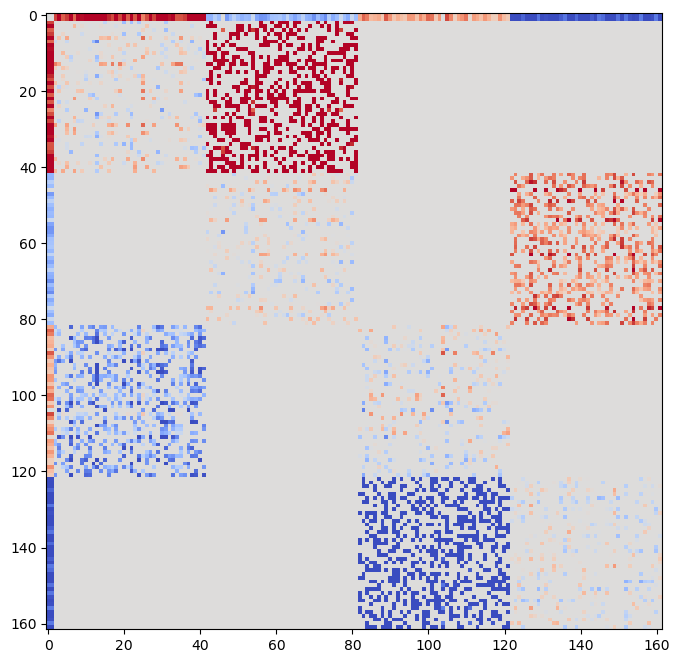

In [26]:
x_sig = U[:, 0]

x_edge = - np.atleast_2d(x_sig) + np.atleast_2d(x_sig).T
x_edge[graph == 0] = 0

x_edge = np.vstack([[x_sig]*2, x_edge])
x_fill = np.vstack([np.zeros((2, 2)), np.array([x_sig]*2).T])
x_edge = np.hstack([x_fill, x_edge])

fig, axes = plt.subplots(figsize=(8, 8))
plt.imshow(x_edge, cmap="coolwarm", vmin=-0.1, vmax=0.1, interpolation="none")